# Regenerate paper figures cleanly

This notebook is a lightweight driver around reusable plotting functions in `slmcal.plotting.paper_figures`. It avoids keeping many NetCDF files open at once and writes each panel separately, so the final composite panels/tables can be assembled outside Python.

In [1]:
from pathlib import Path
import sys

# When running from the repository without installing it:
ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "slmcal").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr

from slmcal.plotting.paper_figures import (
    set_paper_style,
    load_site_datasets,
    plot_site_timeseries,
    plot_monthly_shoreline_distribution,
    plot_wave_rose_by_hs,
    collect_synthetic_metrics,
    plot_emv_heatmaps,
    plot_pca_scatter_grid,
    plot_forcing_timeseries,
    plot_bayesian_marginal_distributions,
    plot_full_uncertainty_bands_with_coverage_panel,
)

set_paper_style()
FIG_DIR = ROOT / "outputs" / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Consistent, colorblind-safe palette used throughout the uncertainty analysis.
UNCERTAINTY_COLORS = {
    "parameter": "#0072B2",
    "reference": "#D55E00",
    "residual": "#009E73",
    "total": "#222222",
    "observation": "#4D4D4D",
    "calibration": "#7A5195",
    "validation": "#EF5675",
}

FIG_DIR


PosixPath('outputs/paper_figures')

## 1. Site data panels

Set the three site files below. These functions generate separate panels for shoreline time series, monthly shoreline distribution, and wave roses.

In [ ]:
SITE_FILES = {
    "Angourie Back Beach": ROOT / "data" / "Angourie_CoastSat_NSWWaves.nc",
    "La Jolla Shores": ROOT / "data" / "LaJolla_CoastSat_CMEMS.nc",
}

START_DATE = pd.Timestamp("1990-01-01")
END_DATE = pd.Timestamp("2024-01-01")

# Keep only files that exist, so the notebook can be run partially.
SITE_FILES = {k: v for k, v in SITE_FILES.items() if v.exists()}
if not SITE_FILES:
    raise FileNotFoundError(f"No site NetCDF files found under {ROOT / 'data'}")

# Raw multi-transect datasets (needed for the PCA figure).
dss_ih_set = load_site_datasets(SITE_FILES)

# Averaged/detrended single-series datasets, as used for calibration.
sites = load_site_datasets(SITE_FILES, source="IH-SET")
list(sites)

In [3]:
from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
def find_pivotal_point(obs, xi, yi, phi):
    """
    Find the pivotal point of the shoreline
    """
    # Interpolação para lidar com valores NaN em obs
    
    Obs_interp = np.zeros_like(obs)
    for i in range(obs.shape[1]):
        Obs_interp[:, i] = np.interp(
            np.arange(len(obs)),
            np.flatnonzero(~np.isnan(obs[:, i])),
            obs[~np.isnan(obs[:, i]), i]
        )

    nans_rot = np.sum(np.isnan(obs), axis=1) > 0.1 * obs.shape[1]
    Obs_interp = Obs_interp[~nans_rot, :]

    
    # Aplicando PCA
    pca = PCA(n_components=obs.shape[1])
    pca.fit(Obs_interp)
    u = pca.components_.T

    # Calculando a distância ao longo da linha xi, yi
    d = np.sqrt((xi - xi[0]) ** 2 + (yi - yi[0]) ** 2)

    # Encontrando a interseção entre o 1º e 2º modos
    # Calculando a diferença entre os dois modos
    diff = u[:, 0] - u[:, 1]

    # Procurando as mudanças de sinal, que indicam pontos de interseção
    sign_changes = np.where(np.diff(np.sign(diff)))[0]

    if len(sign_changes) == 0:
        print("Nenhuma interseção encontrada entre os dois primeiros modos.")
        return None

    # Pega o primeiro ponto de interseção encontrado
    idx = sign_changes[0]

    # Interpolação linear para encontrar a posição exata da interseção
    x1, x2 = d[idx], d[idx + 1]
    y1, y2 = diff[idx], diff[idx + 1]

    # Calculando o ponto de interseção usando interpolação linear
    d_intersect = x1 - y1 * (x2 - x1) / (y2 - y1)

    # Interpolando para encontrar as coordenadas xi, yi e o ângulo phi na interseção
    xi_intersect = np.interp(d_intersect, d, xi)
    yi_intersect = np.interp(d_intersect, d, yi)
    phi_intersect = np.interp(d_intersect, d, phi)

    pivotal_point = {
        'xi': xi_intersect,
        'yi': yi_intersect,
        'phi': phi_intersect
    }

    # # Plot para visualizar os modos e o ponto de interseção
    # plt.figure()
    # plt.plot(d, u[:, 0], color=[0.4, 0.4, 0.4], linewidth=2, label="1st mode")
    # plt.plot(d, u[:, 1], 'k', linewidth=3, label="2nd mode")
    # plt.axvline(d_intersect, color='r', linestyle='--', label='Intersection')
    # plt.grid(True)
    # plt.ylabel("e_n(y)")
    # plt.xlabel("Alongshore distance (m)")
    # plt.legend()
    # plt.show()

    return pivotal_point

Performing PCA analysis for site: Angourie Back Beach


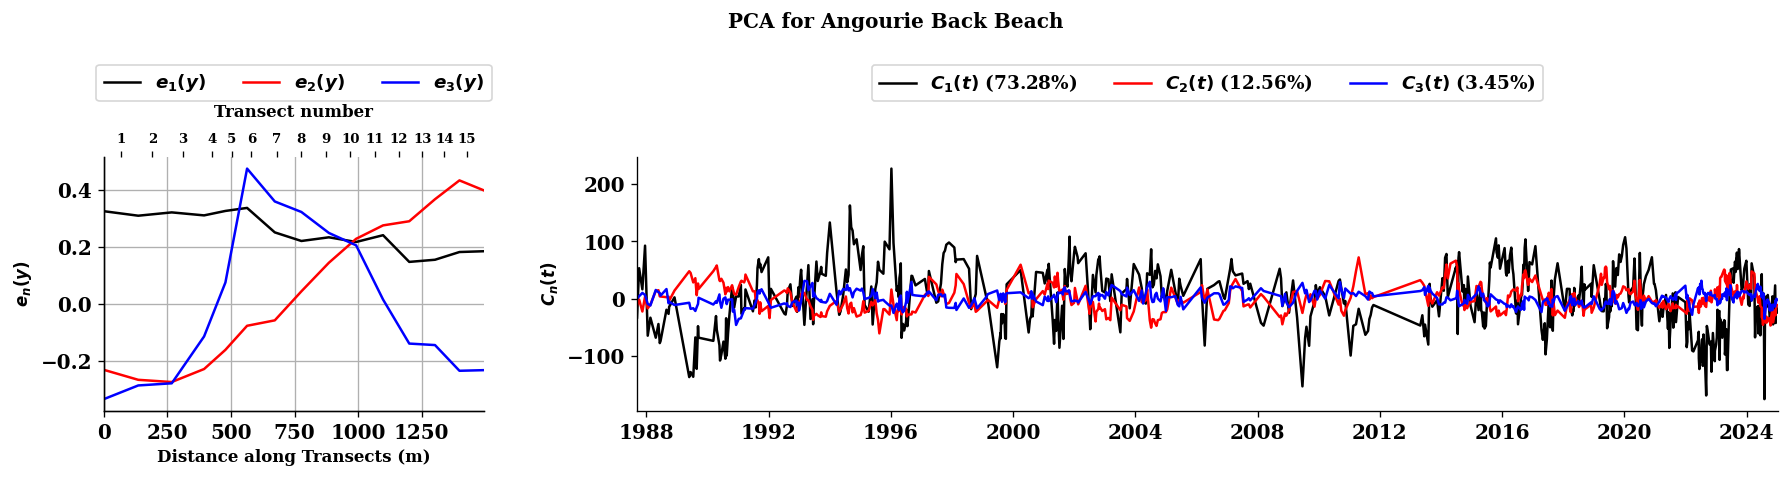

Performing PCA analysis for site: La Jolla Shores


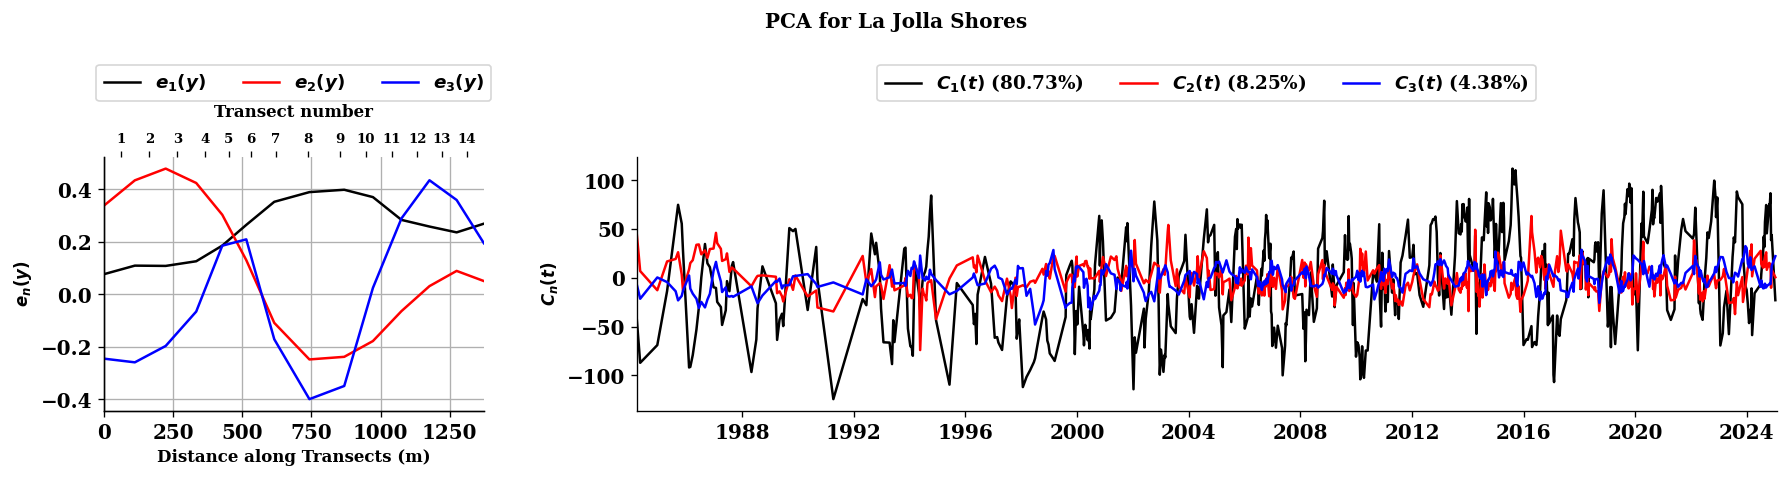

In [4]:
def PCA_Analysis(ds):
        """
        Perform PCA analysis on the observation data
        """
        plt.rcParams.update({'font.family': 'serif'})
        plt.rcParams.update({'font.size': 9})
        plt.rcParams.update({'font.weight': 'bold'})
        font = {'family': 'serif',
                'weight': 'bold',
                'size': 10}
        from sklearn.decomposition import PCA

        # Now we can apply PCA to the observations
        obs = ds.obs.values #[time, transects]
        if obs.ndim != 2:
            raise ValueError(f"Expected obs to be 2D (time_obs, ntrs), got shape {obs.shape}")

        n_transects = obs.shape[1]
        matrix_obs = pd.DataFrame(obs, columns=[f'Transect {i+1}' for i in range(n_transects)])
        matrix_obs['time'] = ds.time_obs
        pca = PCA(n_components=3)
        pca.fit(matrix_obs.drop(columns=['time']).dropna())
        # Transform the observations
        transformed_obs = pca.transform(matrix_obs.drop(columns=['time']).dropna())

        dists = np.sqrt((ds.xi.values[0] - ds.xi.values[1:])**2 + (ds.yi.values[0] - ds.yi.values[1:])**2)
        dists = np.insert(dists, 0, 0)  # Insert 0 for the first transect

        var = pca.explained_variance_ratio_ * 100  # Variance explained by each component in percentage

        u = pca.components_.T
        # And we mark with a vertical line the intersection between components 1 and 2
        diff = u[:, 0] - u[:, 1]
        sign_changes = np.where(np.diff(np.sign(diff)))[0]
        idx = sign_changes[0]

        # Interpolação linear para encontrar a posição exata da interseção
        x1, x2 = dists[idx], dists[idx + 1]
        y1, y2 = diff[idx], diff[idx + 1]
        # Calculando o ponto de interseção usando interpolação linear
        d_intersect = x1 - y1 * (x2 - x1) / (y2 - y1)

        fig, (ax_left, ax_right) = plt.subplots(
            1, 2,
            figsize=(15, 4),
            gridspec_kw={'width_ratios': [1, 3]}  # 1 parte à esquerda, 3 partes à direita → 25% / 75%
        )

        # ======================================================
        # —— PAINEL DA DIREITA (ocupando 75% da largura) ——
        # (aqui você desenha o que antes era o “painel de cima”)
        # ======================================================

        ax_right.plot(
            matrix_obs.dropna()['time'],
            transformed_obs[:, 0],
            label=rf'$C_1 (t)$ ({var[0]:.2f}%)',
            color='black'
        )
        ax_right.plot(
            matrix_obs.dropna()['time'],
            transformed_obs[:, 1],
            label=rf'$C_2 (t)$ ({var[1]:.2f}%)',
            color='red'
        )
        ax_right.plot(
            matrix_obs.dropna()['time'],
            transformed_obs[:, 2],
            label=rf'$C_3 (t)$ ({var[2]:.2f}%)',
            color='blue'
        )
        ax_right.set_ylabel(rf'$C_n (t)$', fontdict=font)
        ax_right.set_xlim(matrix_obs['time'].min(), matrix_obs['time'].max())
        ax_right.legend(ncols=3, loc='upper center', bbox_to_anchor=(0.5, 1.40))
        # ax_right.grid()   # opcional, caso queira grade


        ax_left.plot(dists, u[:, 0], label=rf'$e_1 (y)$', color='black')
        ax_left.plot(dists, u[:, 1], label=rf'$e_2 (y)$', color='red')
        ax_left.plot(dists, u[:, 2], label=rf'$e_3 (y)$', color='blue')

        # ax_left.axvline(x=d_intersect, color='green', linestyle='--', label=rf'$Pivotal Point$')

        ax_left_top = ax_left.twiny()
        ax_left_top.set_xlim(ax_left.get_xlim())
        ax_left_top.set_xticks(dists)
        ax_left_top.set_xticklabels([str(i + 1) for i in range(n_transects)])
        ax_left_top.set_xlabel('Transect number', fontdict=font, labelpad=10)
        ax_left_top.tick_params(axis='x', labelsize=8, pad=3)

        # ax_left.set_xticks(dists)
        # ax_left.set_xticklabels(labels_trs, rotation=45)
        ax_left.set_xlim(0, dists.max())
        ax_left.set_xlabel('Distance along Transects (m)', fontdict=font)
        ax_left.set_ylabel(rf'$e_n (y)$', fontdict=font)
        ax_left.grid()
        ax_left.legend(ncols=3, loc='upper center', bbox_to_anchor=(0.5, 1.40))

        

        plt.tight_layout()
        fig.suptitle(f'PCA for {site_name}', fontsize=12, fontweight='bold')
        fig.savefig(FIG_DIR / f"PCA_{site_name.replace(' ', '_')}.png", dpi=300, bbox_inches='tight') 
        plt.show()


for site_name, ds in dss_ih_set.items():
    print(f"Performing PCA analysis for site: {site_name}")
    PCA_Analysis(ds)

<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3418029/1867227281.py:68: SyntaxWarning: invalid escape sequence '\m'
  r"$N_{data}$" + f" = {n_data} | $\mu$ = {mean:.2f} m | $\sigma$ = {std:.2f} m",
/tmp/ipykernel_3418029/1867227281.py:68: SyntaxWarning: invalid escape sequence '\s'
  r"$N_{data}$" + f" = {n_data} | $\mu$ = {mean:.2f} m | $\sigma$ = {std:.2f} m",
/tmp/ipykernel_3418029/1867227281.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("bwr")
/tmp/ipykernel_3418029/1867227281.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

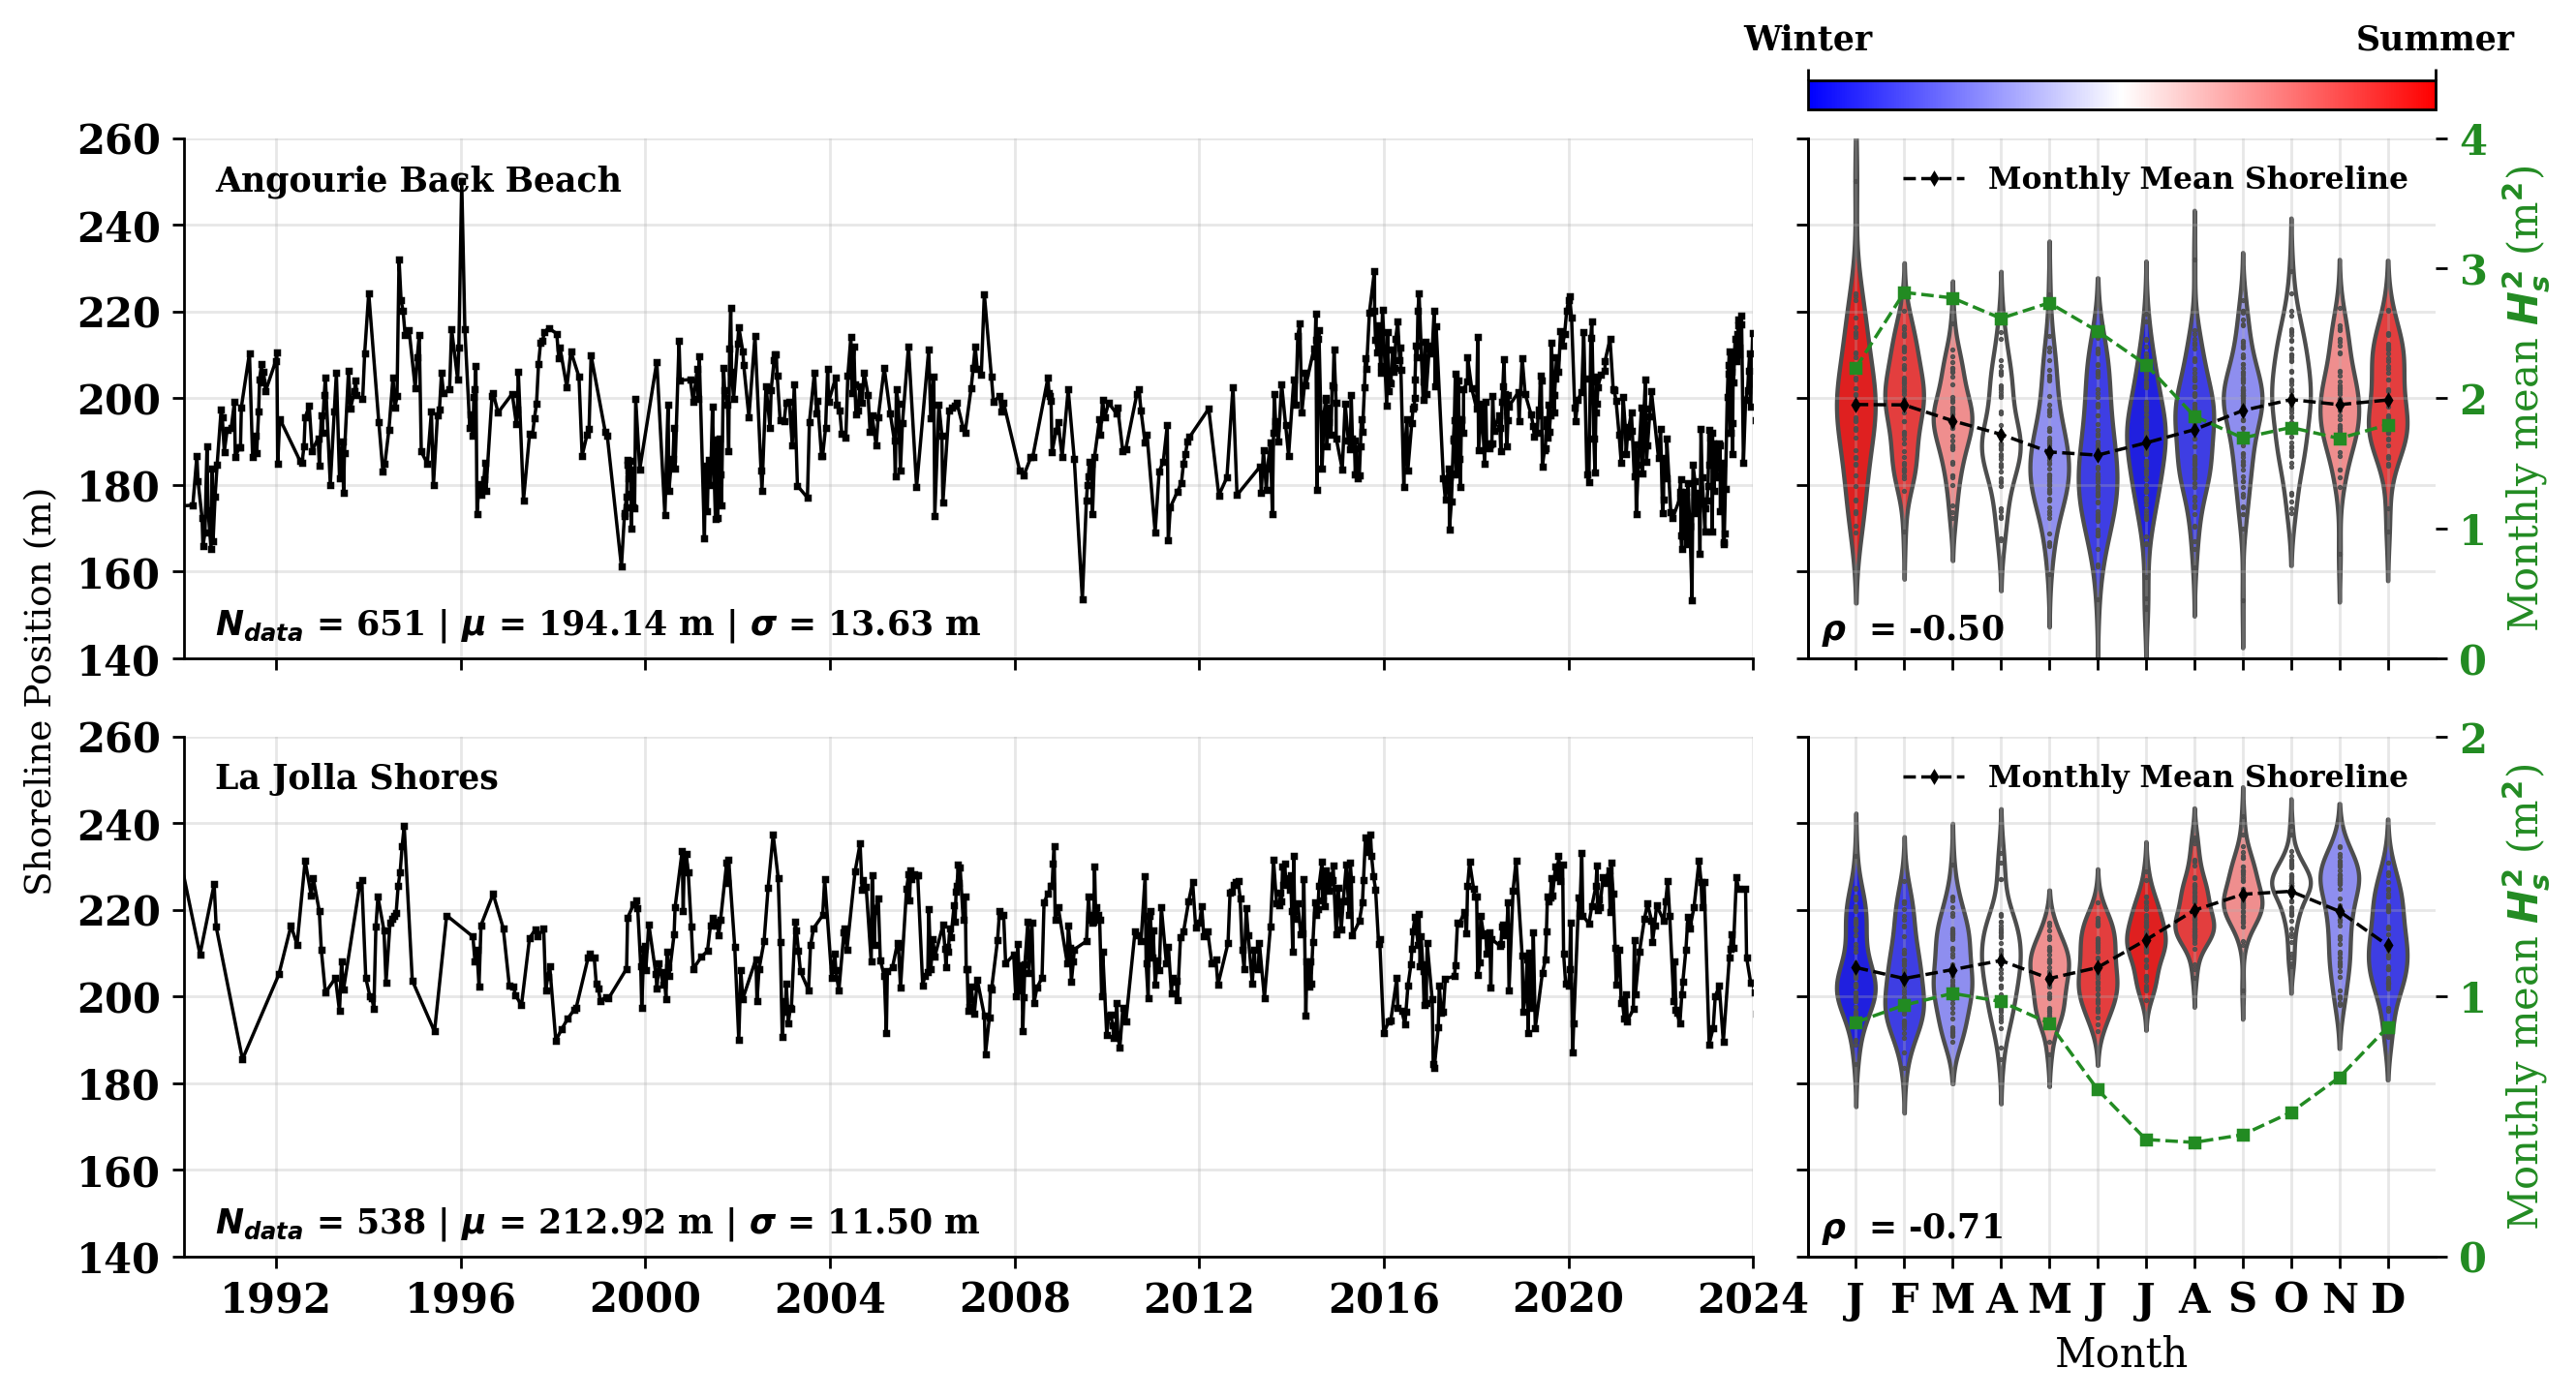

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from scipy.stats import spearmanr
import matplotlib.colors as mcolors

x_lim = (pd.to_datetime('1990-01-01'), pd.to_datetime('2024-01-01'))

x_label_perpetual_month = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# 1) Southern hemisphere months, 1 to 12:
months = np.arange(1, 13)
angles = 2 * np.pi * (months - 1) / 12
T = np.cos(angles)
T_norm = (T + 1) / 2
cmap = cm.get_cmap("bwr")
month_cols = [cmap(t) for t in T_norm]
violin_palette = {str(m): month_cols[m - 1] for m in months}

# Southern hemisphere months, 1 to 12:
angles = 2 * np.pi * (months - 1) / 12 + np.pi
T = np.cos(angles)
T_norm = (T + 1) / 2
month_cols = [cmap(t) for t in T_norm]
violin_palette_n = {str(m): month_cols[m - 1] for m in months}

# 3. Make a figure with 2×2 axes, but left column 3× wider than right:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 6),
    sharey="row",
    gridspec_kw={
        "width_ratios": [3, 1.2],
        "wspace": 0.05,
        "height_ratios": [1, 1],
        "hspace": 0.15,
    },
    dpi=250,
)

# 4. Plot your time-series on the left (3/4 width):
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = cm.Reds
step_reduction = 30

site_items = list(sites.items())
labels = ["Angourie Back Beach", "La Jolla Shores"]

for ax, (site_name, ds), label in zip(axes[:, 0], site_items, labels):
    ds["obs"].plot(
        ax=ax,
        marker="s",
        linestyle="-",
        color="black",
        label=label,
        linewidth=1,
        markersize=1,
    )
    ii_start = np.argmin(np.abs(pd.to_datetime(ds["obs"].time_obs.values) - x_lim[0]))
    ii_end = np.argmin(np.abs(pd.to_datetime(ds["obs"].time_obs.values) - x_lim[1]))
    n_data = len(ds["obs"].values[ii_start:ii_end])
    std = ds["obs"].std().values
    mean = ds["obs"].mean().values
    ax.text(
        0.02,
        0.1,
        r"$N_{data}$" + f" = {n_data} | $\mu$ = {mean:.2f} m | $\sigma$ = {std:.2f} m",
        transform=ax.transAxes,
        fontsize=10,
        color="black",
        fontweight="bold",
        va="top",
        ha="left",
    )
    ax.set_ylim([140, 260])

# 5. Violin + swarm on the right (1/4 width):
palette_by_site = [violin_palette, violin_palette_n]

for (ax, (site_name, ds), pal_vio) in zip(axes[:, 1], site_items, palette_by_site):
    sns.violinplot(
        x=ds["obs"].time_obs.dt.month,
        y=ds["obs"],
        ax=ax,
        scale="count",
        inner="point",
        bw="silverman",
        palette=pal_vio,
        inner_kws={
            "marker": ".",
            "s": 1,
            "zorder": 2,
        },
        zorder=1,
        label="",
    )
    monthly_mean = ds["obs"].groupby("time_obs.month").mean()
    ax.plot(
        np.arange(len(monthly_mean)),
        monthly_mean.values,
        color="black",
        linewidth=1.0,
        linestyle="--",
        marker="d",
        markersize=2,
        label="Monthly Mean Shoreline",
        zorder=3,
    )

    ds["E"] = ds["hs"] ** 2
    monthly_mean_E = ds["E"].groupby("time.month").mean()

    if site_name == "Angourie Back Beach":
        ylim_ = (0, 4)
    else:
        ylim_ = (0, 2)

    ax2 = ax.twinx()
    ax2.plot(
        np.arange(len(monthly_mean_E)),
        monthly_mean_E.values,
        color="forestgreen",
        linewidth=1.0,
        linestyle="--",
        marker="s",
        markersize=3,
        label="$H_s^2$ Monthly Mean",
        zorder=3,
    )

    ax2.set_ylim(ylim_)
    ax2.tick_params(axis="y", labelcolor="forestgreen")

    corr_monthly_mean = spearmanr(monthly_mean.values, monthly_mean_E.values)[0]
    ax2.text(
        0.02,
        0.02,
        r"$\rho$ " + f" = {corr_monthly_mean:.2f}",
        transform=ax2.transAxes,
        fontsize=10,
        va="bottom",
        ha="left",
    )
    # ylabel and yticks
    ax2.set_ylabel("Monthly mean $H_s^2$ (m$^2$)", color="forestgreen")
    ax2.set_yticks(np.arange(ylim_[0], ylim_[1] + 1, 1))

    ax.set_ylabel("")
    ax.set_xticks(np.arange(0, 12))
    # if ax is axes[1, 1]:
    #     ax.legend(loc="lower right", fontsize=9, frameon=False)
    # else:
    ax.legend(loc="upper right", fontsize=9, frameon=False)

# 6. Final tweaks:
for ax in axes.flat:
    ax.grid(alpha=0.3)

axes[0, 0].set_xlim(x_lim)
axes[1, 0].set_xlim(x_lim)

axes[0, 0].text(
    0.02,
    0.95,
    "Angourie Back Beach",
    transform=axes[0, 0].transAxes,
    fontsize=10,
    color="black",
    fontweight="bold",
    va="top",
    ha="left",
)
axes[1, 0].text(
    0.02,
    0.95,
    "La Jolla Shores",
    transform=axes[1, 0].transAxes,
    fontsize=10,
    color="black",
    fontweight="bold",
    va="top",
    ha="left",
)

axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")
axes[0, 0].set_xticklabels("")

axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("")

axes[0, 1].set_xticklabels("")
axes[0, 1].set_xlabel("")

axes[1, 1].set_xlabel("Month")
axes[1, 1].set_xticklabels(x_label_perpetual_month)

import matplotlib.colors as mcolors

# 1) Make a ScalarMappable with the same bwr cmap you used for the months
#    Normalize from 0→1 so that 0=red (summer), 1=blue (winter).
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap="bwr")
sm.set_array([])

# 2) Grab the position of the top violin-axis:
pos = axes[0, 1].get_position()

# 3) Create a new, thin axis sitting just above it:
cax = fig.add_axes([
    pos.x0,
    pos.y1 + 0.02,
    pos.width,
    0.02,
])

# 4) Draw the horizontal colorbar into that new axis:
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", ticks=[0, 1])

# 5) Put “Summer” under the red end (tick 0) and “Winter” under the blue (tick 1),
#    and move the tick labels to the _top_ of the bar:
cbar.ax.set_xticklabels(["Winter", "Summer"], fontsize=10, color="black")
cbar.ax.xaxis.set_ticks_position("top")

fig.supylabel("Shoreline Position (m)", x=0.07, y=0.5, va="center", rotation="vertical")

fig.savefig(
    str(FIG_DIR / "shoreline_monthly_distributions.png"),
    dpi=300,
)



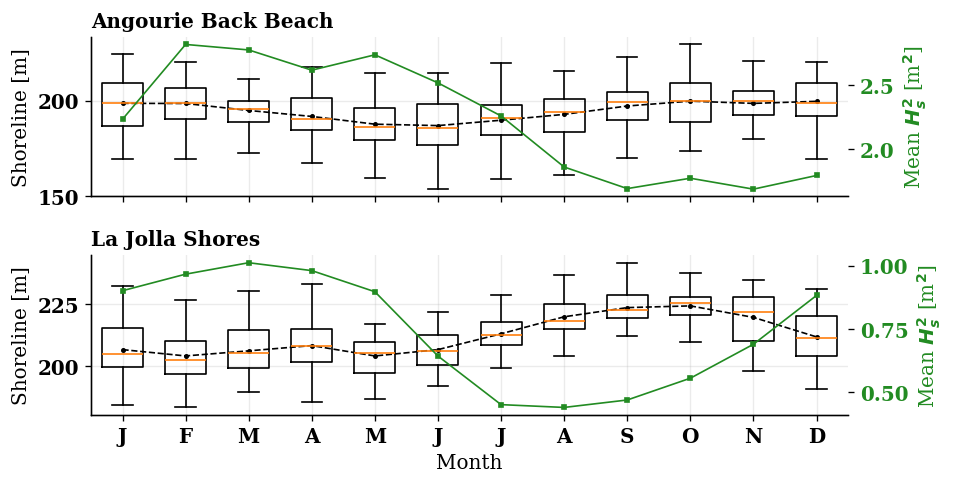

In [6]:
if sites:
    fig, axes = plot_monthly_shoreline_distribution(
        sites,
        out_path=FIG_DIR / "site_monthly_shoreline_distribution.png",
    )
    plt.show()

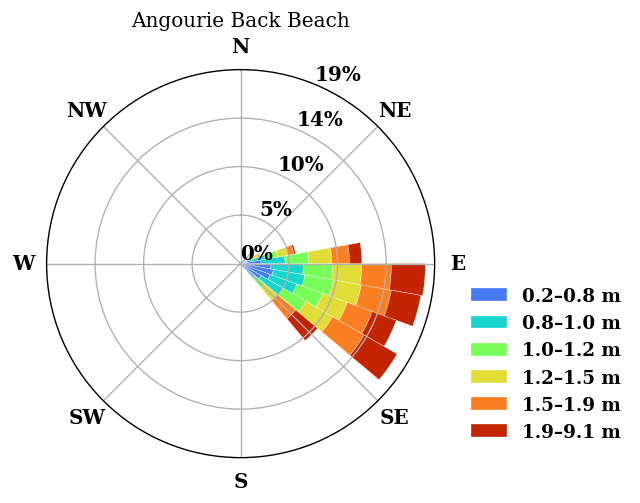

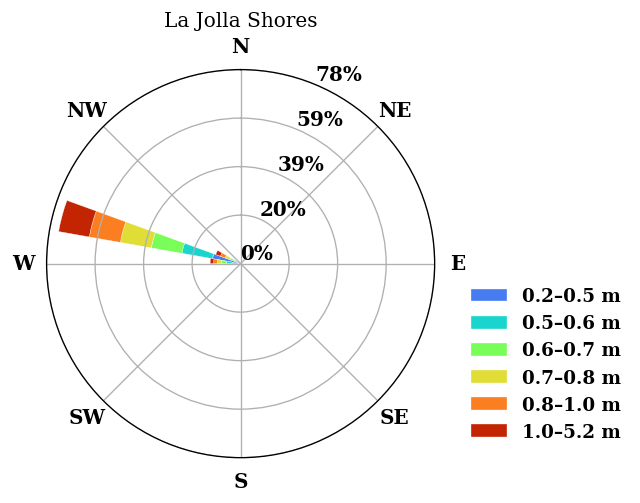

In [7]:
# Individual wave rose panels, one file per site.
for label, ds in sites.items():
    safe = label.lower().replace(" ", "_").replace("/", "_")
    fig, ax = plot_wave_rose_by_hs(ds, cmap="turbo", out_path=FIG_DIR / f"wave_rose_{safe}.png")
    ax.set_title(label)
    plt.show()

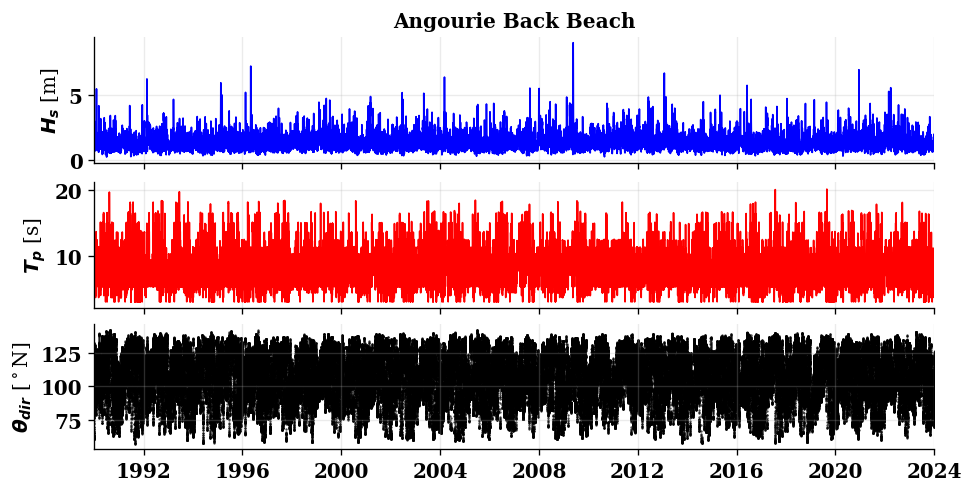

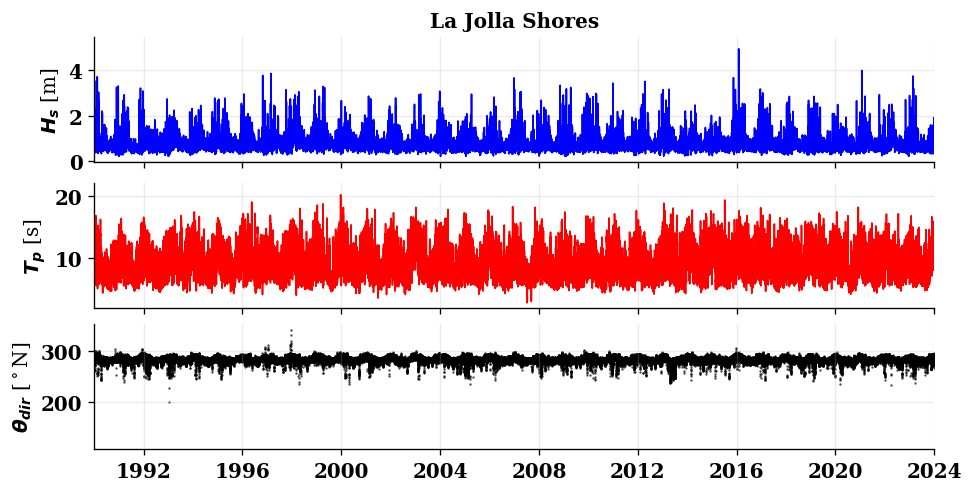

In [8]:
for label, ds in sites.items():
    fig, ax = plot_forcing_timeseries(ds, start_date=START_DATE, end_date=END_DATE)
    ax[0].set_title(label, fontsize=12, fontweight='bold')
    plt.show()

    fig.savefig(FIG_DIR / f"forcing_timeseries_{label.lower().replace(' ', '_').replace('/', '_')}.png", dpi=300)


## 2. Bayesian propagation with identifiable uncertainty sources

The Bayesian posterior is propagated into three sources that can be interpreted consistently across sites:

1. **Dynamic/physical-parameter uncertainty**, associated with the calibrated model parameters;
2. **Reference-position uncertainty**, combining the initial shoreline position \(Y_0\) and the additive observation/model bias;
3. **Residual predictive uncertainty**, represented by \(\sigma z(t)\).

The reference trajectory is

\[
\tilde Y(t)=f(\tilde{\boldsymbol\theta},\tilde Y_0)+\tilde b,
\]

and every posterior realization satisfies

\[
Y_i(t)=\tilde Y(t)+E_{\theta,i}(t)+E_{R,i}(t)+E_{\sigma,i}(t).
\]

The interaction between physical parameters and \(Y_0\) is divided symmetrically using a two-factor Shapley allocation. The centered bias is then added to the reference-position effect. This grouping is used because a single shoreline record generally constrains \(Y_0+b\) more robustly than \(Y_0\) and \(b\) independently.

For the variance budget, the residual contribution is evaluated analytically as \(E[\sigma^2]\). Therefore, random Monte Carlo fluctuations in the stored residual realizations do not appear as artificial temporal variability in the uncertainty attribution.


In [9]:
ARTIFACT_DIRS = {
    "Angourie": (
        ROOT
        / "outputs"
        / "Angourie"
        / "Vitousek21Yates"
        / "bayesian_artifacts"
    ),
    "La Jolla": (
        ROOT
        / "outputs"
        / "LaJolla"
        / "Vitousek21Yates"
        / "bayesian_artifacts"
    ),
}

SITE_DATA_KEYS = {
    "Angourie": "Angourie Back Beach",
    "La Jolla": "La Jolla Shores",
}


def _orient_ensemble(arr, time):
    """Return an ensemble with shape [draw, time]."""
    arr = np.asarray(arr, dtype=float)
    n_time = len(time)

    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D ensemble, got {arr.shape}.")

    if arr.shape[1] == n_time:
        return arr
    if arr.shape[0] == n_time:
        return arr.T

    raise ValueError(
        f"Cannot align ensemble shape {arr.shape} with {n_time} times."
    )


def _sample_covariance(a, b):
    """Finite-sample covariance over posterior draws at each time."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if a.shape != b.shape:
        raise ValueError(f"Covariance shapes differ: {a.shape} vs {b.shape}.")

    a_anom = a - np.nanmean(a, axis=0, keepdims=True)
    b_anom = b - np.nanmean(b, axis=0, keepdims=True)

    return np.nansum(a_anom * b_anom, axis=0) / max(1, a.shape[0] - 1)


def load_reference_uncertainty_artifacts(artifact_dir):
    """Load version-4 artifacts and reconstruct the predictive ensembles."""
    artifact_dir = Path(artifact_dir)
    propagation_file = artifact_dir / "uncertainty_propagator.npz"
    sampler_file = artifact_dir / "bayesian_parameter_sampler.npz"

    if not propagation_file.exists():
        raise FileNotFoundError(propagation_file)
    if not sampler_file.exists():
        raise FileNotFoundError(sampler_file)

    with np.load(propagation_file, allow_pickle=True) as z:
        version = (
            int(np.asarray(z["artifact_format_version"]).squeeze())
            if "artifact_format_version" in z.files
            else 0
        )
        required = {
            "time",
            "parameter_effect",
            "reference_position_effect",
            "residual_noise",
        }
        missing = required.difference(z.files)
        if version < 4 or missing:
            raise KeyError(
                "The artifacts must be regenerated with the reference-position "
                f"outputs.py (format version 4). Missing: {sorted(missing)}."
            )

        time = pd.to_datetime(np.asarray(z["time"]))
        deterministic = np.asarray(
            z["deterministic_reference"]
            if "deterministic_reference" in z.files
            else z["deterministic"],
            dtype=float,
        ).squeeze()

        parameter_effect = _orient_ensemble(z["parameter_effect"], time)
        reference_effect = _orient_ensemble(
            z["reference_position_effect"],
            time,
        )
        residual_noise = _orient_ensemble(z["residual_noise"], time)

        propagation_draw_index = (
            np.asarray(z["draw_index"], dtype=int).ravel()
            if "draw_index" in z.files
            else None
        )
        bias_reference = (
            float(np.asarray(z["bias_reference"]).squeeze())
            if "bias_reference" in z.files
            else np.nan
        )
        y0_reference = (
            float(np.asarray(z["y0_reference"]).squeeze())
            if "y0_reference" in z.files
            else np.nan
        )

    if deterministic.ndim != 1 or deterministic.size != len(time):
        raise ValueError(
            "The deterministic reference must be one-dimensional and aligned "
            f"with time; got {deterministic.shape}."
        )

    if not (
        parameter_effect.shape
        == reference_effect.shape
        == residual_noise.shape
    ):
        raise ValueError(
            "The propagated effects are not aligned: "
            f"{parameter_effect.shape}, {reference_effect.shape}, "
            f"{residual_noise.shape}."
        )

    with np.load(sampler_file, allow_pickle=True) as z:
        sampler = {key: np.asarray(z[key]) for key in z.files}

    sampler_draw_index = (
        np.asarray(sampler["draw_index"], dtype=int).ravel()
        if "draw_index" in sampler
        else None
    )
    if (
        propagation_draw_index is not None
        and sampler_draw_index is not None
        and not np.array_equal(
            propagation_draw_index,
            sampler_draw_index,
        )
    ):
        raise ValueError(
            "The posterior sampler and propagated ensembles use different draws."
        )

    n_draws = parameter_effect.shape[0]
    for name in ("sigma", "bias", "y0"):
        if name in sampler:
            values = np.asarray(sampler[name]).ravel()
            if values.size != n_draws:
                raise ValueError(
                    f"{name} has {values.size} draws but propagation has "
                    f"{n_draws}."
                )

    baseline = deterministic[None, :]
    latent = baseline + parameter_effect + reference_effect
    full = latent + residual_noise

    reconstruction_error = np.nanmax(
        np.abs(
            full
            - (
                baseline
                + parameter_effect
                + reference_effect
                + residual_noise
            )
        )
    )

    return {
        "time": time,
        "deterministic": deterministic,
        "parameter_effect": parameter_effect,
        "reference_effect": reference_effect,
        "residual_noise": residual_noise,
        "latent": latent,
        "full": full,
        "sampler": sampler,
        "n_draws": n_draws,
        "bias_reference": bias_reference,
        "y0_reference": y0_reference,
        "reconstruction_error_m": float(reconstruction_error),
    }


def _extract_observations(ds):
    """Return a clean, alongshore-averaged shoreline observation series."""
    obs_names = ("obs", "Obs", "shoreline", "Y")
    time_names = ("time_obs", "obs_time", "time")

    obs_name = next((name for name in obs_names if name in ds), None)
    if obs_name is None:
        raise KeyError(
            f"No shoreline variable found. Tried {obs_names}; "
            f"available={list(ds.data_vars)}."
        )

    da = ds[obs_name]
    time_name = next(
        (
            name
            for name in time_names
            if name in da.dims or name in ds.coords or name in ds
        ),
        None,
    )
    if time_name is None:
        raise KeyError(
            f"No observation-time variable found. Tried {time_names}."
        )

    if time_name in da.dims:
        reduce_dims = [dim for dim in da.dims if dim != time_name]
        if reduce_dims:
            da = da.mean(dim=reduce_dims, skipna=True)
        times = pd.to_datetime(np.asarray(da[time_name].values))
        values = np.asarray(da.values, dtype=float).ravel()
    else:
        values = np.asarray(da.values, dtype=float)
        if values.ndim > 1:
            values = np.nanmean(values, axis=tuple(range(1, values.ndim)))
        values = values.ravel()
        times = pd.to_datetime(np.asarray(ds[time_name].values).ravel())

    n = min(values.size, times.size)
    out = pd.DataFrame(
        {"time": times[:n], "shoreline": values[:n]}
    )
    out = (
        out.replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values("time")
        .drop_duplicates("time")
        .reset_index(drop=True)
    )
    return out


def _nearest_time_indices(model_time, target_time):
    """Nearest model indices for irregular observation times."""
    model_ns = pd.DatetimeIndex(model_time).asi8
    target_ns = pd.DatetimeIndex(target_time).asi8

    right = np.searchsorted(model_ns, target_ns, side="left")
    right = np.clip(right, 0, len(model_ns) - 1)
    left = np.clip(right - 1, 0, len(model_ns) - 1)

    choose_right = (
        np.abs(model_ns[right] - target_ns)
        < np.abs(model_ns[left] - target_ns)
    )
    return np.where(choose_right, right, left)


def _central_interval_coverage(samples, observations, levels):
    """Observed coverage of central posterior predictive intervals."""
    samples = np.asarray(samples, dtype=float)
    observations = np.asarray(observations, dtype=float)
    rows = []

    for level in levels:
        lower_q = 50.0 * (1.0 - level)
        upper_q = 100.0 - lower_q
        lower, upper = np.nanpercentile(
            samples,
            [lower_q, upper_q],
            axis=0,
        )
        covered = (observations >= lower) & (observations <= upper)
        rows.append(
            {
                "nominal": float(level),
                "observed": float(np.nanmean(covered)),
                "n_obs": int(np.sum(np.isfinite(observations))),
            }
        )

    return pd.DataFrame(rows)


In [10]:
# ============================================================================
# CHECK THE ACTUAL NUMBER OF SAVED POSTERIOR AND PROPAGATED DRAWS
# ============================================================================

draw_check_rows = []

for site, artifact_dir in ARTIFACT_DIRS.items():

    artifact_dir = Path(artifact_dir)

    sampler_file = (
        artifact_dir
        / "bayesian_parameter_sampler.npz"
    )

    propagation_file = (
        artifact_dir
        / "uncertainty_propagator.npz"
    )

    row = {
        "site": site,
        "sampler_exists": sampler_file.exists(),
        "propagator_exists": propagation_file.exists(),
    }

    if sampler_file.exists():

        with np.load(
            sampler_file,
            allow_pickle=True,
        ) as z:

            row["sampler_keys"] = ", ".join(z.files)

            for key in (
                "draw_index",
                "sigma",
                "bias",
                "y0",
                "log_delta_y",
                "log_delta_t_days",
                "log_hhat",
            ):
                if key in z.files:
                    row[f"sampler_{key}_shape"] = str(
                        np.asarray(z[key]).shape
                    )

            if "draw_index" in z.files:
                draw_index = np.asarray(
                    z["draw_index"]
                ).ravel()

                row["n_sampler_draw_index"] = (
                    draw_index.size
                )

                row["n_unique_sampler_draws"] = (
                    np.unique(draw_index).size
                )

    if propagation_file.exists():

        with np.load(
            propagation_file,
            allow_pickle=True,
        ) as z:

            row["propagator_keys"] = ", ".join(
                z.files
            )

            for key in (
                "draw_index",
                "parameter_effect",
                "reference_position_effect",
                "residual_noise",
            ):
                if key in z.files:
                    row[f"propagator_{key}_shape"] = str(
                        np.asarray(z[key]).shape
                    )

            if "draw_index" in z.files:
                draw_index = np.asarray(
                    z["draw_index"]
                ).ravel()

                row["n_propagator_draw_index"] = (
                    draw_index.size
                )

                row["n_unique_propagated_draws"] = (
                    np.unique(draw_index).size
                )

            if "parameter_effect" in z.files:
                parameter_effect = np.asarray(
                    z["parameter_effect"]
                )

                row["parameter_effect_axis0"] = (
                    parameter_effect.shape[0]
                )

                row["parameter_effect_axis1"] = (
                    parameter_effect.shape[1]
                    if parameter_effect.ndim > 1
                    else np.nan
                )

    draw_check_rows.append(row)


draw_check = pd.DataFrame(
    draw_check_rows
).set_index("site")

display(draw_check.T)

site,Angourie,La Jolla
sampler_exists,True,True
propagator_exists,True,True
sampler_keys,"posterior_raw, posterior_physical, prior_raw, ...","posterior_raw, posterior_physical, prior_raw, ..."
sampler_draw_index_shape,"(1000,)","(1000,)"
sampler_sigma_shape,"(1000,)","(1000,)"
sampler_bias_shape,"(1000,)","(1000,)"
sampler_y0_shape,"(1000,)","(1000,)"
n_sampler_draw_index,1000,1000
n_unique_sampler_draws,1000,1000
propagator_keys,"artifact_format_version, time, draw_index, det...","artifact_format_version, time, draw_index, det..."


In [11]:
print(sites["Angourie Back Beach"].obs[0])
print(sites["La Jolla Shores"].obs[0])

<xarray.DataArray 'obs' ()> Size: 8B
array(182.026599)
Coordinates:
    time_obs  datetime64[ns] 8B 1987-09-11T23:09:17
<xarray.DataArray 'obs' ()> Size: 8B
array(215.162031)
Coordinates:
    time_obs  datetime64[ns] 8B 1984-03-23T17:50:13


In [ ]:

for (SITE, OBS_DATASET), (_, ARTIFACT_DIR) in zip(sites.items(), ARTIFACT_DIRS.items()):

    SPLIT_DATE = "2010-01-01"
    MODEL_NAME = "VY21"
    START_DATE = "1990-01-01"
    END_DATE = "2024-01-01"

    fig, axes, coverage_df = plot_full_uncertainty_bands_with_coverage_panel(
        ARTIFACT_DIR,
        obs_dataset=OBS_DATASET,
        obs_names=("obs", "Obs", "shoreline"),
        obs_time_names=("time_obs", "obs_time", "time"),
        split_date=SPLIT_DATE,
        start_date=START_DATE,
        end_date=END_DATE,
        label=f"{SITE} — {MODEL_NAME}",
        comp="full",
        coverage_levels=np.linspace(0.50, 1.00, 100),
        match_tolerance="3D",
        figsize=(12.5, 3.2),
        out_path=FIG_DIR / f"{SITE}_{MODEL_NAME}_full_uncertainty_with_coverage_panel.png",
    )

    # Clean publication labels after the reusable plotting function returns.
    legend_label_map = {
        "5-95%": "5–95% interval",
        "2.5-97.5%": "2.5–97.5% interval",
        "median": "Posterior median",
        "observations": "SDS observations",
        "cal/val split": "Calibration–validation split",
    }

    legends = list(fig.legends)
    legends.extend(
        ax.get_legend()
        for ax in fig.axes
        if ax.get_legend() is not None
    )

    for legend in legends:
        for text in legend.get_texts():
            current = text.get_text()
            text.set_text(
                legend_label_map.get(
                    current,
                    current,
                )
            )

    # The function saves before these labels are edited, so overwrite
    # the output once more with the final publication-ready labels.
    final_out_path = (
        FIG_DIR
        / f"{SITE}_{MODEL_NAME}_full_uncertainty_with_coverage_panel.png"
    )
    fig.savefig(
        final_out_path,
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()
    # display(coverage_df)

src/slmcal/plotting/paper_figures.py:2489: RuntimeWarning: The uncertainty summary was not found or did not contain quantiles for 'full'. Reconstructing the full ensemble as a compatibility fallback; regenerating the Bayesian artifacts with the current outputs.py will make this plot substantially faster.
  warnings.warn(


In [ ]:
# Compact source-spread files produced during artifact generation.
# These files now contain valid newline-delimited CSV records.
for site, artifact_dir in ARTIFACT_DIRS.items():
    metrics_file = artifact_dir / "uncertainty_spread_metrics.csv"
    if metrics_file.exists():
        print(f"\n{site}")
        display(pd.read_csv(metrics_file))



Angourie


,component,mean_std,mean_emv,median_emv,p95_emv
0,physical_parameter_only,1.535219,13.580177,13.194000,16.540381
1,reference_position_only,1.418794,12.626785,12.626785,12.626785
2,latent_shoreline,1.045704,6.571897,5.899948,10.862799
3,residual_only,10.504082,68.613558,68.107635,78.235519
4,full,10.569363,69.018912,68.486862,78.786499
5,parameter_effect,1.535219,13.580177,13.194003,16.540383
6,reference_position_effect,1.418794,12.626787,12.626787,12.626787
7,residual_noise,10.504082,68.613558,68.107639,78.235526



La Jolla


,component,mean_std,mean_emv,median_emv,p95_emv
0,physical_parameter_only,3.780231,25.558468,25.154251,29.962302
1,reference_position_only,3.757388,25.051796,25.051804,25.051804
2,latent_shoreline,0.774306,5.349918,4.586952,10.934428
3,residual_only,7.798543,50.947537,50.580635,58.065347
4,full,7.842715,51.240610,50.874123,58.407535
5,parameter_effect,3.780231,25.558468,25.154255,29.962306
6,reference_position_effect,3.757388,25.051800,25.051800,25.051800
7,residual_noise,7.798543,50.947537,50.580626,58.065350


## 4. Posterior parameter and reference-position diagnostics

Prior–posterior marginal comparisons are followed by dependence diagnostics that use the identifiable reference offset $Y_0+b$. The raw $Y_0$–bias relationship is retained only as an identifiability diagnostic.


In [ ]:
obs_o = [182.026599, 215.162031]

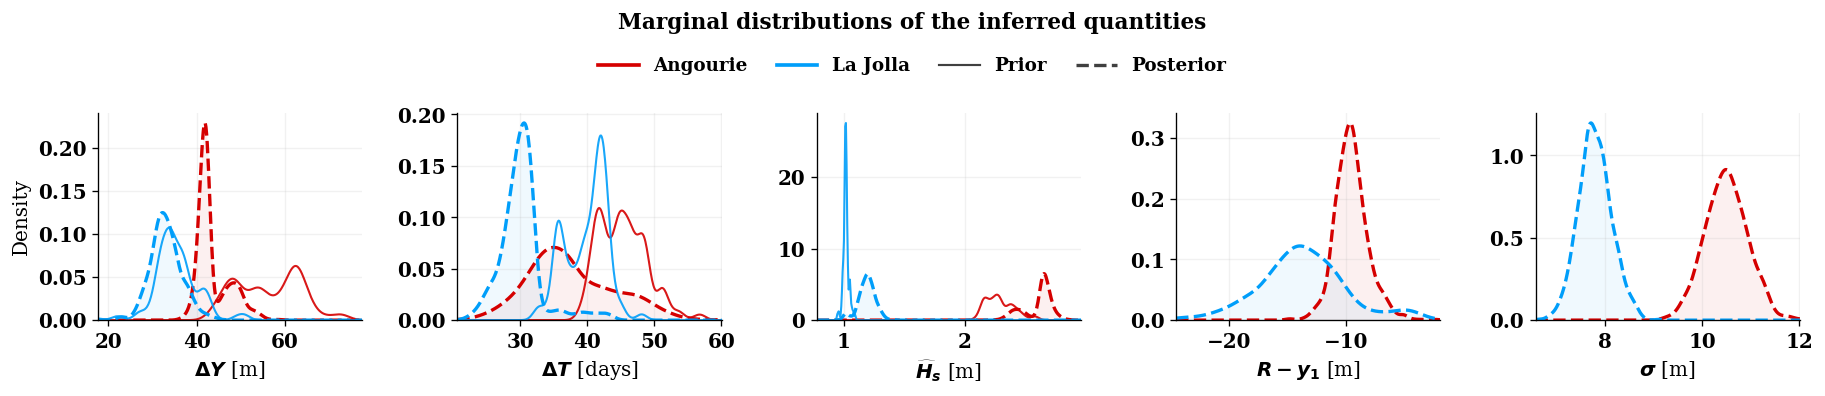

,site,source,variable,n,mean,sd,q05,q50,q95
0,Angourie,posterior,log_delta_y,1000,43.606847,3.654143,39.886922,42.233801,50.854652
1,Angourie,prior,log_delta_y,1000,56.355519,7.347264,46.131520,55.817434,66.431661
2,La Jolla,posterior,log_delta_y,1000,33.110272,3.536627,27.681926,32.837151,39.226879
3,La Jolla,prior,log_delta_y,1000,35.376440,4.871871,28.510227,34.618140,42.822822
4,Angourie,posterior,log_delta_t_days,1000,37.825267,7.088963,28.109004,36.567967,49.491602
5,Angourie,prior,log_delta_t_days,1000,45.276065,3.533225,40.517684,44.922089,51.398679
6,La Jolla,posterior,log_delta_t_days,1000,30.114226,3.257207,25.378151,30.055919,36.405297
7,La Jolla,prior,log_delta_t_days,1000,39.868134,3.107323,35.346050,40.914696,43.116877
8,Angourie,posterior,log_hhat,1000,2.603163,0.117943,2.373628,2.642482,2.742697
9,Angourie,prior,log_hhat,1000,2.288793,0.116601,2.136285,2.265435,2.497136


In [ ]:
def _display_parameter_label(name):
    """Consistent LaTeX label for physical model parameters."""
    cleaned = str(name).lower()

    if "delta_y" in cleaned or cleaned == "deltay":
        return r"$\Delta Y$ [m]"

    if "delta_t_acc" in cleaned:
        return r"$\Delta T_{\mathrm{acc}}$ [days]"

    if "delta_t_ero" in cleaned:
        return r"$\Delta T_{\mathrm{ero}}$ [days]"

    if "delta_t" in cleaned or cleaned == "deltat":
        return r"$\Delta T$ [days]"

    if "hhat" in cleaned or "h_hat" in cleaned:
        return r"$\widehat{H}_{s}$ [m]"

    return str(name)


def plot_identifiable_posterior_marginals(
    artifact_dirs,
    *,
    colors,
    out_path=None,
    summary_csv=None,
):
    """Plot physical parameters, R=Y0+b and sigma with clean global legends."""
    from matplotlib.lines import Line2D
    from scipy.stats import gaussian_kde

    loaded = {}
    summary_rows = []

    for [site, artifact_dir], obs_ini in zip(artifact_dirs.items(), obs_o):
        sampler_file = (
            Path(artifact_dir)
            / "bayesian_parameter_sampler.npz"
        )

        if not sampler_file.exists():
            continue

        with np.load(
            sampler_file,
            allow_pickle=True,
        ) as z:
            posterior_physical = np.asarray(
                z["posterior_physical"],
                dtype=float,
            )

            prior_physical = (
                np.asarray(z["prior_physical"], dtype=float)
                if "prior_physical" in z.files
                else None
            )

            param_names = [
                value.decode("utf-8")
                if isinstance(value, bytes)
                else str(value)
                for value in np.asarray(
                    z["param_names"]
                ).ravel()
            ]

            # Centre the identifiable reference position on the first
            # shoreline observation so that both sites share a comparable axis.
            # The plotted quantity is therefore R - y_1, not the absolute R.
            y0 = np.asarray(
                z["y0"],
                dtype=float,
            ).ravel() - obs_ini

            bias = np.asarray(
                z["bias"],
                dtype=float,
            ).ravel()

            sigma = np.asarray(
                z["sigma"],
                dtype=float,
            ).ravel()

        reference_offset = y0 + bias

        loaded[site] = {
            "posterior_physical": posterior_physical,
            "prior_physical": prior_physical,
            "param_names": param_names,
            "reference_offset": reference_offset,
            "sigma": sigma,
        }

    if not loaded:
        raise FileNotFoundError(
            "No Bayesian parameter samplers were found."
        )

    first_site = next(iter(loaded))
    parameter_names = loaded[first_site]["param_names"]

    variables = [
        ("physical", index, name)
        for index, name in enumerate(parameter_names)
    ] + [
        ("reference", None, r"$R-y_1$ [m]"),
        ("sigma", None, r"$\sigma$ [m]"),
    ]

    n_panels = len(variables)

    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(3.05 * n_panels, 3.45),
        constrained_layout=False,
    )
    axes = np.atleast_1d(axes)

    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        bottom=0.18,
        top=0.68,
        wspace=0.36,
    )

    for panel_index, (ax, variable) in enumerate(
        zip(axes, variables)
    ):
        kind, parameter_index, name = variable

        pooled = []

        for site_data in loaded.values():
            if kind == "physical":
                pooled.append(
                    site_data["posterior_physical"][:, parameter_index]
                )
                if site_data["prior_physical"] is not None:
                    pooled.append(
                        site_data["prior_physical"][:, parameter_index]
                    )
            elif kind == "reference":
                pooled.append(site_data["reference_offset"])
            else:
                pooled.append(site_data["sigma"])

        pooled = np.concatenate(
            [
                np.asarray(values, dtype=float)[
                    np.isfinite(values)
                ]
                for values in pooled
            ]
        )

        lower, upper = np.nanquantile(
            pooled,
            [0.005, 0.995],
        )

        if np.isclose(lower, upper):
            half_width = max(
                abs(float(lower)) * 0.05,
                1e-3,
            )
            lower -= half_width
            upper += half_width

        padding = 0.10 * (upper - lower)
        lower -= padding
        upper += padding

        if kind == "sigma":
            lower = max(0.0, lower)

        grid = np.linspace(
            lower,
            upper,
            400,
        )

        for site, site_data in loaded.items():
            color = colors[site]

            if kind == "physical":
                posterior_values = (
                    site_data["posterior_physical"][:, parameter_index]
                )
                prior_values = (
                    None
                    if site_data["prior_physical"] is None
                    else site_data["prior_physical"][:, parameter_index]
                )
                x_label = _display_parameter_label(name)
                variable_name = str(name)
            elif kind == "reference":
                posterior_values = site_data["reference_offset"]
                prior_values = None
                x_label = name
                variable_name = "reference_position_relative_to_first_observation"
            else:
                posterior_values = site_data["sigma"]
                prior_values = None
                x_label = name
                variable_name = "sigma"

            posterior_values = np.asarray(
                posterior_values,
                dtype=float,
            )
            posterior_values = posterior_values[
                np.isfinite(posterior_values)
            ]

            posterior_density = gaussian_kde(
                posterior_values
            )(grid)

            ax.plot(
                grid,
                posterior_density,
                color=color,
                linestyle="--",
                linewidth=2.0,
            )

            ax.fill_between(
                grid,
                0.0,
                posterior_density,
                color=color,
                alpha=0.06,
                linewidth=0,
            )

            summary_rows.append(
                {
                    "site": site,
                    "source": "posterior",
                    "variable": variable_name,
                    "n": posterior_values.size,
                    "mean": float(np.mean(posterior_values)),
                    "sd": float(np.std(posterior_values, ddof=1)),
                    "q05": float(np.quantile(posterior_values, 0.05)),
                    "q50": float(np.quantile(posterior_values, 0.50)),
                    "q95": float(np.quantile(posterior_values, 0.95)),
                }
            )

            if prior_values is not None:
                prior_values = np.asarray(
                    prior_values,
                    dtype=float,
                )
                prior_values = prior_values[
                    np.isfinite(prior_values)
                ]

                prior_density = gaussian_kde(
                    prior_values
                )(grid)

                ax.plot(
                    grid,
                    prior_density,
                    color=color,
                    linestyle="-",
                    linewidth=1.25,
                    alpha=0.90,
                )

                summary_rows.append(
                    {
                        "site": site,
                        "source": "prior",
                        "variable": variable_name,
                        "n": prior_values.size,
                        "mean": float(np.mean(prior_values)),
                        "sd": float(np.std(prior_values, ddof=1)),
                        "q05": float(np.quantile(prior_values, 0.05)),
                        "q50": float(np.quantile(prior_values, 0.50)),
                        "q95": float(np.quantile(prior_values, 0.95)),
                    }
                )

        ax.set_xlabel(x_label)
        ax.set_xlim(lower, upper)
        ax.set_ylim(bottom=0.0)
        ax.grid(alpha=0.17)

        if panel_index == 0:
            ax.set_ylabel("Density")
        else:
            ax.set_ylabel("")

        # if kind in {"reference", "sigma"}:
        #     ax.text(
        #         0.98,
        #         0.93,
        #         "posterior only",
        #         transform=ax.transAxes,
        #         ha="right",
        #         va="top",
        #         fontsize=8,
        #         color="0.40",
        #     )

    site_handles = [
        Line2D(
            [0],
            [0],
            color=colors[site],
            linewidth=2.2,
            label=site,
        )
        for site in loaded
    ]

    style_handles = [
        Line2D(
            [0],
            [0],
            color="0.25",
            linestyle="-",
            linewidth=1.3,
            label="Prior",
        ),
        Line2D(
            [0],
            [0],
            color="0.25",
            linestyle="--",
            linewidth=2.0,
            label="Posterior",
        ),
    ]

    fig.legend(
        handles=site_handles + style_handles,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.855),
        ncol=len(site_handles) + len(style_handles),
        columnspacing=1.6,
        handlelength=2.2,
    )

    fig.suptitle(
        "Marginal distributions of the inferred quantities",
        fontsize=13,
        fontweight="bold",
        y=0.925,
    )

    # fig.text(
    #     0.5,
    #     0.755,
    #     (
    #         r"The identifiable reference position is "
    #         r"$R=Y_0+b$; $R$ and $\sigma$ are shown as posterior marginals."
    #     ),
    #     ha="center",
    #     va="center",
    #     fontsize=9.2,
    #     color="0.35",
    # )

    summary_df = pd.DataFrame(summary_rows)

    if summary_csv is not None:
        summary_csv = Path(summary_csv)
        summary_csv.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        summary_df.to_csv(
            summary_csv,
            index=False,
        )

    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        fig.savefig(
            out_path,
            dpi=350,
            bbox_inches="tight",
        )

    return fig, axes, summary_df


BAYESIAN_MARGINAL_DIRS = ARTIFACT_DIRS

BAYESIAN_MARGINAL_COLORS = {
    "Angourie": "#D50000",
    "La Jolla": "#009EFA",
}

fig, axes, posterior_summary = (
    plot_identifiable_posterior_marginals(
        BAYESIAN_MARGINAL_DIRS,
        colors=BAYESIAN_MARGINAL_COLORS,
        out_path=(
            FIG_DIR
            / "vitousek21_identifiable_prior_posterior_marginals.png"
        ),
        summary_csv=(
            FIG_DIR
            / "vitousek21_identifiable_prior_posterior_marginals_summary.csv"
        ),
    )
)

plt.show()
display(posterior_summary)

## 5. Identifiable uncertainty attribution

The variance budget compares physical-parameter, reference-position and residual predictive uncertainty. Residual variance is evaluated as $E[\sigma^2]$, while posterior dependence is represented only by $2\,\mathrm{Cov}(E_\theta,E_R)$.


In [ ]:
def decompose_identifiable_uncertainty_sources(
    artifact_dir,
    *,
    out_csv=None,
    out_fig=None,
    title="Posterior predictive uncertainty budget",
    max_plot_points=12_000,
):
    """Exact variance budget for parameters, reference position and residuals.

    The predictive model is

        full = deterministic_reference
               + parameter_effect
               + reference_position_effect
               + residual_noise.

    The residual term has conditional mean zero.  Its exact posterior variance
    is therefore E[sigma**2], and its covariance with the other two effects is
    zero in expectation.  The only posterior-dependence term retained in the
    scientific budget is 2*Cov(parameter_effect, reference_position_effect).
    """
    art = load_reference_uncertainty_artifacts(artifact_dir)

    time = art["time"]
    parameter_effect = art["parameter_effect"]
    reference_effect = art["reference_effect"]
    residual_noise = art["residual_noise"]
    full = art["full"]
    sampler = art["sampler"]

    sigma = np.asarray(
        sampler.get("sigma", np.array([])),
        dtype=float,
    ).ravel()
    sigma = sigma[np.isfinite(sigma) & (sigma >= 0)]
    if sigma.size == 0:
        residual_variance = 0.0
    else:
        residual_variance = float(np.mean(sigma**2))

    var_parameter = np.nanvar(parameter_effect, axis=0, ddof=1)
    var_reference = np.nanvar(reference_effect, axis=0, ddof=1)
    cov_parameter_reference = _sample_covariance(
        parameter_effect,
        reference_effect,
    )
    twice_cov_parameter_reference = 2.0 * cov_parameter_reference

    var_residual = np.full_like(
        var_parameter,
        residual_variance,
        dtype=float,
    )

    var_latent = (
        var_parameter
        + var_reference
        + twice_cov_parameter_reference
    )
    var_total_exact = var_latent + var_residual

    # The stored full ensemble uses one Gaussian residual realization per draw.
    # It is used only as a finite-Monte-Carlo diagnostic, not for attribution.
    var_total_mc = np.nanvar(full, axis=0, ddof=1)
    mc_relative_error = np.divide(
        var_total_mc - var_total_exact,
        var_total_exact,
        out=np.full_like(var_total_exact, np.nan),
        where=var_total_exact > 0,
    )

    isolated_sum = var_parameter + var_reference + var_residual
    parameter_share = np.divide(
        var_parameter,
        isolated_sum,
        out=np.full_like(var_parameter, np.nan),
        where=isolated_sum > 0,
    )
    reference_share = np.divide(
        var_reference,
        isolated_sum,
        out=np.full_like(var_reference, np.nan),
        where=isolated_sum > 0,
    )
    residual_share = np.divide(
        var_residual,
        isolated_sum,
        out=np.full_like(var_residual, np.nan),
        where=isolated_sum > 0,
    )

    effect_correlation = np.divide(
        cov_parameter_reference,
        np.sqrt(var_parameter * var_reference),
        out=np.full_like(cov_parameter_reference, np.nan),
        where=(var_parameter > 0) & (var_reference > 0),
    )
    effect_correlation = np.clip(effect_correlation, -1.0, 1.0)

    # Equal allocation of the parameter-reference covariance.  These net
    # allocations sum to the exact total variance but can be negative when
    # posterior compensation is very strong.
    allocated_parameter = var_parameter + cov_parameter_reference
    allocated_reference = var_reference + cov_parameter_reference
    allocated_residual = var_residual

    df = pd.DataFrame(
        {
            "time": time,
            "var_physical_parameters": var_parameter,
            "var_reference_position": var_reference,
            "var_residual_predictive": var_residual,
            "twice_cov_parameters_reference":
                twice_cov_parameter_reference,
            "effect_correlation_parameters_reference":
                effect_correlation,
            "var_latent_shoreline": var_latent,
            "var_total_exact": var_total_exact,
            "var_total_mc": var_total_mc,
            "mc_relative_error": mc_relative_error,
            "parameter_standalone_share": parameter_share,
            "reference_standalone_share": reference_share,
            "residual_standalone_share": residual_share,
            "allocated_parameter_variance": allocated_parameter,
            "allocated_reference_variance": allocated_reference,
            "allocated_residual_variance": allocated_residual,
        }
    )

    mean_vp = float(np.nanmean(var_parameter))
    mean_vr = float(np.nanmean(var_reference))
    mean_vs = float(residual_variance)
    mean_cov2 = float(np.nanmean(twice_cov_parameter_reference))
    mean_total = float(np.nanmean(var_total_exact))
    mean_isolated = mean_vp + mean_vr + mean_vs

    summary_data = {
        "n_draws": int(art["n_draws"]),
        "mean_physical_parameter_variance_m2": mean_vp,
        "mean_reference_position_variance_m2": mean_vr,
        "residual_predictive_variance_m2": mean_vs,
        "mean_twice_cov_parameters_reference_m2": mean_cov2,
        "mean_latent_shoreline_variance_m2":
            float(np.nanmean(var_latent)),
        "mean_total_predictive_variance_m2": mean_total,
        "mean_total_predictive_sd_m": float(np.sqrt(mean_total)),
        "physical_parameter_standalone_share_%":
            100.0 * mean_vp / mean_isolated,
        "reference_position_standalone_share_%":
            100.0 * mean_vr / mean_isolated,
        "residual_predictive_standalone_share_%":
            100.0 * mean_vs / mean_isolated,
        "parameter_reference_covariance_fraction_of_total_%":
            100.0 * mean_cov2 / mean_total,
        "mean_parameter_reference_effect_correlation":
            float(np.nanmean(effect_correlation)),
        "mean_abs_MC_variance_error_%":
            100.0 * float(np.nanmean(np.abs(mc_relative_error))),
        "reconstruction_error_m": art["reconstruction_error_m"],
        "posterior_mean_sigma_m":
            float(np.mean(sigma)) if sigma.size else 0.0,
        "E_sigma2_m2": mean_vs,
        "reference_bias_median_m": art["bias_reference"],
        "reference_y0_median_m": art["y0_reference"],
    }

    y0 = np.asarray(sampler.get("y0", np.array([])), dtype=float).ravel()
    bias = np.asarray(
        sampler.get("bias", np.array([])),
        dtype=float,
    ).ravel()
    valid = (
        np.isfinite(y0)
        & np.isfinite(bias)
        if y0.size == bias.size and y0.size
        else np.array([], dtype=bool)
    )
    if valid.size and np.sum(valid) > 2:
        reference_offset = y0[valid] + bias[valid]
        summary_data["posterior_reference_offset_variance_m2"] = float(
            np.var(reference_offset, ddof=1)
        )
        summary_data["raw_y0_bias_spearman"] = float(
            spearmanr(y0[valid], bias[valid]).statistic
        )

    summary = pd.Series(summary_data)

    step = max(1, int(np.ceil(len(df) / max_plot_points)))
    dp = df.iloc[::step]

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(11.7, 8.8),
        sharex=True,
        constrained_layout=True,
    )

    ax = axes[0]
    ax.plot(
        dp["time"],
        dp["var_physical_parameters"],
        color=UNCERTAINTY_COLORS["parameter"],
        linewidth=1.05,
        label="Physical parameters",
    )
    ax.plot(
        dp["time"],
        dp["var_reference_position"],
        color=UNCERTAINTY_COLORS["reference"],
        linewidth=1.05,
        label=r"Reference position ($Y_0+b$)",
    )
    ax.plot(
        dp["time"],
        dp["var_residual_predictive"],
        color=UNCERTAINTY_COLORS["residual"],
        linewidth=1.15,
        label=r"Residual ($E[\sigma^2]$)",
    )
    ax.plot(
        dp["time"],
        dp["var_total_exact"],
        color=UNCERTAINTY_COLORS["total"],
        linewidth=1.25,
        label="Total predictive variance",
    )
    ax.set_ylabel("Variance [m²]")
    ax.set_title("a) Source-specific and total variance", loc="left", fontweight="bold")
    ax.grid(alpha=0.18)
    ax.legend(
        frameon=False,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.20),
    )

    ax = axes[1]
    ax.stackplot(
        dp["time"],
        100.0 * dp["parameter_standalone_share"],
        100.0 * dp["reference_standalone_share"],
        100.0 * dp["residual_standalone_share"],
        colors=[
            UNCERTAINTY_COLORS["parameter"],
            UNCERTAINTY_COLORS["reference"],
            UNCERTAINTY_COLORS["residual"],
        ],
        alpha=0.82,
        labels=[
            "Physical parameters",
            "Reference position",
            "Residual",
        ],
    )
    ax.set_ylim(0, 100)
    ax.set_ylabel("Isolated variance share [%]")
    ax.set_title(
        "b) Relative isolated-source spread",
        loc="left",
        fontweight="bold",
    )
    ax.grid(alpha=0.14)
    ax.legend(
        frameon=False,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.17),
    )

    ax = axes[2]
    covariance = dp["twice_cov_parameters_reference"].to_numpy()
    ax.plot(
        dp["time"],
        covariance,
        color="#CC79A7",
        linewidth=1.0,
        label=r"$2\,\mathrm{Cov}(E_\theta,E_R)$",
    )
    ax.fill_between(
        dp["time"],
        0.0,
        covariance,
        where=covariance >= 0,
        color="#CC79A7",
        alpha=0.18,
        linewidth=0,
    )
    ax.fill_between(
        dp["time"],
        0.0,
        covariance,
        where=covariance < 0,
        color="#666666",
        alpha=0.16,
        linewidth=0,
    )
    ax.axhline(0.0, color="0.35", linestyle="--", linewidth=0.8)
    ax.set_ylabel("Covariance term [m²]")
    ax.set_xlabel("Time")
    ax.set_title(
        "c) Posterior dependence between dynamic and reference effects",
        loc="left",
        fontweight="bold",
    )
    ax.grid(alpha=0.18)

    ax_corr = ax.twinx()
    ax_corr.plot(
        dp["time"],
        dp["effect_correlation_parameters_reference"],
        color="0.25",
        linewidth=0.75,
        alpha=0.72,
        label=r"$\rho(E_\theta,E_R)$",
    )
    ax_corr.set_ylim(-1.05, 1.05)
    ax_corr.set_ylabel("Effect correlation")
    ax_corr.yaxis.set_major_locator(MaxNLocator(5))

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax_corr.get_legend_handles_labels()
    ax.legend(
        handles1 + handles2,
        labels1 + labels2,
        frameon=False,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.16),
    )

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.025)

    if out_csv is not None:
        out_csv = Path(out_csv)
        out_csv.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_csv, index=False)

    if out_fig is not None:
        out_fig = Path(out_fig)
        out_fig.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_fig, dpi=350, bbox_inches="tight")

    return df, summary, fig, axes



Angourie


,value
n_draws,1000.000000
raw_y0_bias_spearman,-0.950470
reference_offset_mean_m,172.491434
reference_offset_sd_m,1.419504
y0_sd_m,4.718740
bias_sd_m,4.534857
sigma_mean_m,10.502090


,$\Delta Y$,$\Delta T$,$\widehat{H}_s$,$R=Y_0+b$,$\sigma$
$\Delta Y$,1.00,0.58,-0.61,-0.09,-0.22
$\Delta T$,0.58,1.00,-0.63,0.28,-0.23
$\widehat{H}_s$,-0.61,-0.63,1.00,-0.48,0.16
$R=Y_0+b$,-0.09,0.28,-0.48,1.00,0.02
$\sigma$,-0.22,-0.23,0.16,0.02,1.00


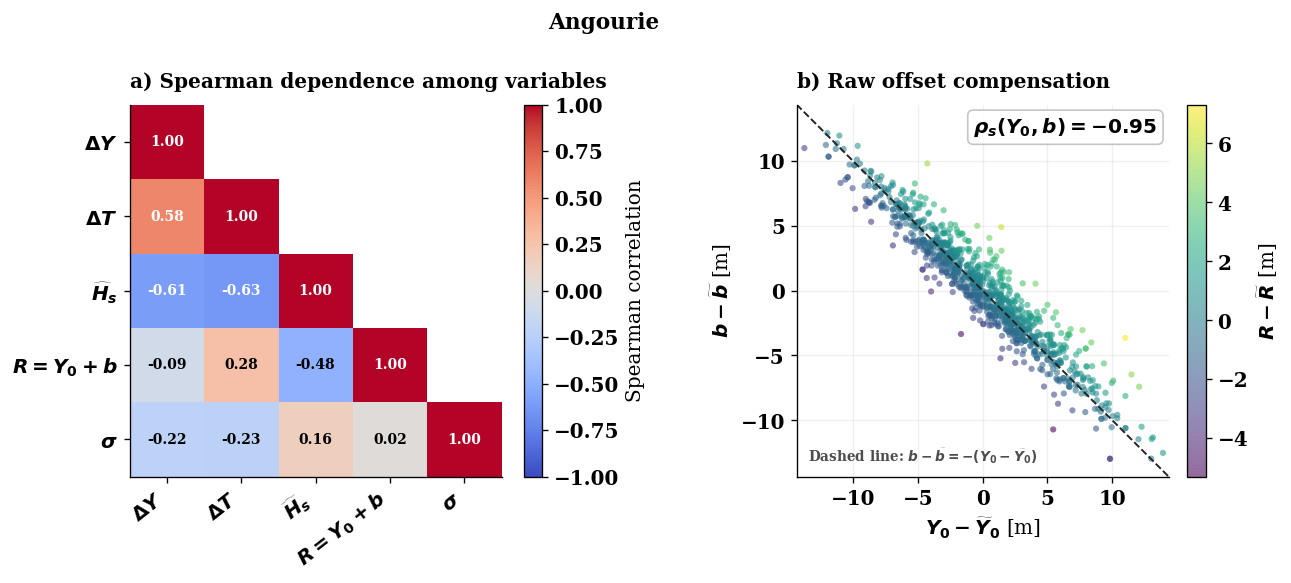


La Jolla


,value
n_draws,1000.000000
raw_y0_bias_spearman,-0.694617
reference_offset_mean_m,201.500824
reference_offset_sd_m,3.759268
y0_sd_m,5.204217
bias_sd_m,4.441082
sigma_mean_m,7.796178


,$\Delta Y$,$\Delta T$,$\widehat{H}_s$,$R=Y_0+b$,$\sigma$
$\Delta Y$,1.00,-0.25,0.80,-0.89,-0.05
$\Delta T$,-0.25,1.00,-0.48,0.42,0.01
$\widehat{H}_s$,0.80,-0.48,1.00,-0.97,-0.05
$R=Y_0+b$,-0.89,0.42,-0.97,1.00,0.05
$\sigma$,-0.05,0.01,-0.05,0.05,1.00


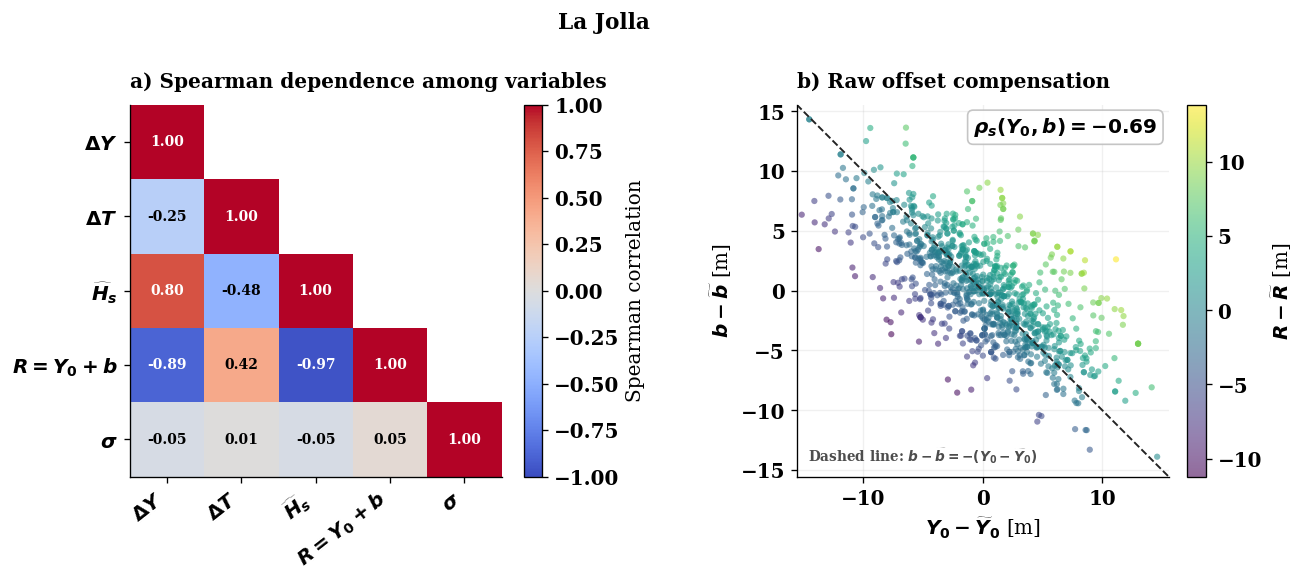

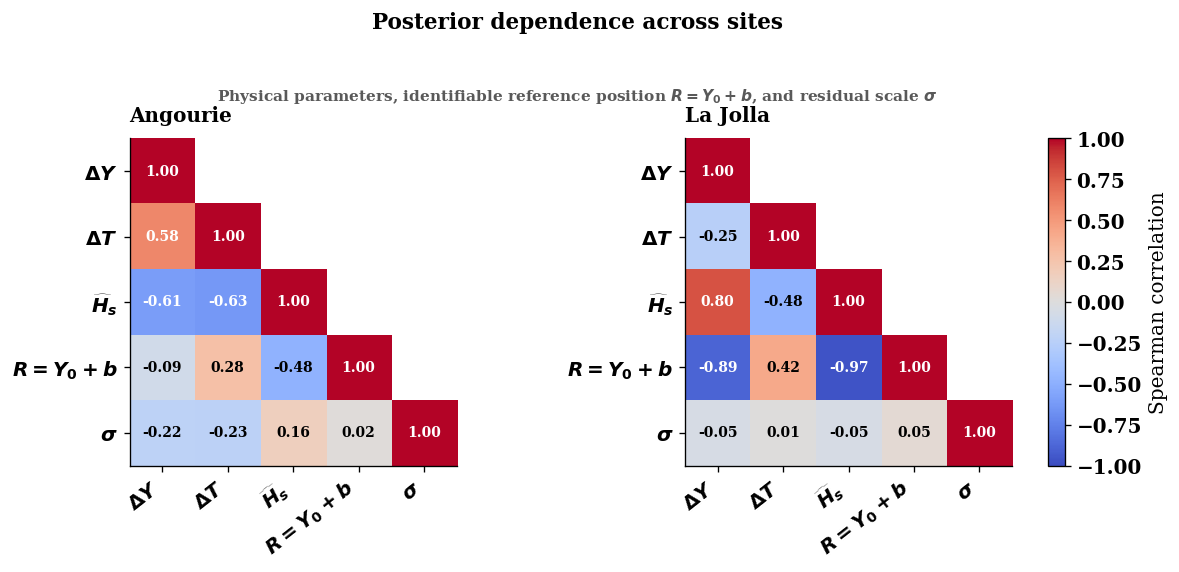

In [ ]:
def _parameter_symbol(name):
    """Map raw or transformed parameter names to publication labels."""
    cleaned = str(name).lower()

    if "delta_y" in cleaned or cleaned == "deltay":
        return r"$\Delta Y$"

    if "delta_t_acc" in cleaned:
        return r"$\Delta T_{\mathrm{acc}}$"

    if "delta_t_ero" in cleaned:
        return r"$\Delta T_{\mathrm{ero}}$"

    if "delta_t" in cleaned or cleaned == "deltat":
        return r"$\Delta T$"

    if "hhat" in cleaned or "h_hat" in cleaned:
        return r"$\widehat{H}_s$"

    return str(name)


def _plot_lower_triangle_correlation(
    ax,
    corr,
    *,
    title,
):
    """Lower-triangular Spearman correlation matrix without duplication."""
    values = corr.to_numpy(dtype=float)
    upper_mask = np.triu(
        np.ones_like(values, dtype=bool),
        k=1,
    )

    masked = np.ma.masked_where(
        upper_mask,
        values,
    )

    cmap = plt.get_cmap("coolwarm").copy()
    cmap.set_bad("white")

    image = ax.imshow(
        masked,
        vmin=-1.0,
        vmax=1.0,
        cmap=cmap,
        aspect="equal",
    )

    labels = list(corr.columns)
    indices = np.arange(len(labels))

    ax.set_xticks(indices)
    ax.set_yticks(indices)
    ax.set_xticklabels(
        labels,
        rotation=38,
        ha="right",
    )
    ax.set_yticklabels(labels)

    for i in range(values.shape[0]):
        for j in range(i + 1):
            value = values[i, j]
            text_color = (
                "white"
                if abs(value) >= 0.58
                else "black"
            )
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.3,
                color=text_color,
            )

    ax.set_title(
        title,
        loc="left",
        fontweight="bold",
        pad=10,
    )

    return image


def posterior_reference_dependence_diagnostics(
    artifact_dir,
    *,
    site,
    out_path=None,
    out_prefix=None,
):
    """Posterior dependence using the identifiable reference offset R=Y0+b."""
    artifact_dir = Path(artifact_dir)
    sampler_file = (
        artifact_dir
        / "bayesian_parameter_sampler.npz"
    )

    with np.load(
        sampler_file,
        allow_pickle=True,
    ) as z:
        physical = np.asarray(
            z["posterior_physical"],
            dtype=float,
        )
        names = [
            value.decode("utf-8")
            if isinstance(value, bytes)
            else str(value)
            for value in np.asarray(
                z["param_names"]
            ).ravel()
        ]
        y0 = np.asarray(
            z["y0"],
            dtype=float,
        ).ravel()
        bias = np.asarray(
            z["bias"],
            dtype=float,
        ).ravel()
        sigma = np.asarray(
            z["sigma"],
            dtype=float,
        ).ravel()

    n = physical.shape[0]

    for label, values in (
        ("y0", y0),
        ("bias", bias),
        ("sigma", sigma),
    ):
        if values.size != n:
            raise ValueError(
                f"{label} has {values.size} draws; expected {n}."
            )

    reference_offset = y0 + bias

    data = {
        _parameter_symbol(name): physical[:, index]
        for index, name in enumerate(names)
    }
    data[r"$R=Y_0+b$"] = reference_offset
    data[r"$\sigma$"] = sigma

    posterior_df = pd.DataFrame(data).replace(
        [np.inf, -np.inf],
        np.nan,
    )
    corr = posterior_df.corr(
        method="spearman"
    )

    y0_anomaly = y0 - np.nanmedian(y0)
    bias_anomaly = bias - np.nanmedian(bias)
    reference_anomaly = (
        reference_offset
        - np.nanmedian(reference_offset)
    )

    raw_df = pd.DataFrame(
        {
            "y0": y0,
            "bias": bias,
            "reference_offset": reference_offset,
            "y0_anomaly": y0_anomaly,
            "bias_anomaly": bias_anomaly,
            "reference_offset_anomaly": reference_anomaly,
            "sigma": sigma,
        }
    ).replace(
        [np.inf, -np.inf],
        np.nan,
    )

    valid_raw = raw_df[
        ["y0", "bias"]
    ].dropna()

    raw_rho = (
        float(
            spearmanr(
                valid_raw["y0"],
                valid_raw["bias"],
            ).statistic
        )
        if len(valid_raw) > 2
        else np.nan
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12.0, 5.0),
        gridspec_kw={
            "width_ratios": [1.20, 1.0],
        },
        constrained_layout=False,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.92,
        bottom=0.17,
        top=0.79,
        wspace=0.38,
    )

    image = _plot_lower_triangle_correlation(
        axes[0],
        corr,
        title=(
            "a) Spearman dependence among "
            "variables"
        ),
    )

    colorbar = fig.colorbar(
        image,
        ax=axes[0],
        fraction=0.046,
        pad=0.04,
    )
    colorbar.set_label(
        "Spearman correlation"
    )

    ax = axes[1]

    scatter = ax.scatter(
        raw_df["y0_anomaly"],
        raw_df["bias_anomaly"],
        c=raw_df["reference_offset_anomaly"],
        cmap="viridis",
        s=14,
        alpha=0.58,
        linewidth=0,
    )

    finite_anomalies = raw_df[
        ["y0_anomaly", "bias_anomaly"]
    ].to_numpy(dtype=float)
    finite_anomalies = finite_anomalies[
        np.all(np.isfinite(finite_anomalies), axis=1)
    ]

    limit = float(
        np.nanquantile(
            np.abs(finite_anomalies),
            0.995,
        )
    )
    limit = max(limit, 1e-6)
    limit *= 1.10

    diagonal = np.linspace(
        -limit,
        limit,
        200,
    )

    ax.plot(
        diagonal,
        -diagonal,
        color=UNCERTAINTY_COLORS["total"],
        linewidth=1.15,
        linestyle="--",
    )

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect(
        "equal",
        adjustable="box",
    )
    ax.set_xlabel(
        r"$Y_0-\widetilde{Y}_0$ [m]"
    )
    ax.set_ylabel(
        r"$b-\widetilde{b}$ [m]"
    )
    ax.set_title(
        "b) Raw offset compensation",
        loc="left",
        fontweight="bold",
        pad=10,
    )
    ax.grid(alpha=0.18)

    ax.text(
        0.97,
        0.97,
        rf"$\rho_s(Y_0,b)={raw_rho:.2f}$",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": "white",
            "edgecolor": "0.75",
            "alpha": 0.90,
        },
    )

    ax.text(
        0.03,
        0.03,
        (
            r"Dashed line: "
            r"$b-\widetilde b="
            r"-(Y_0-\widetilde Y_0)$"
        ),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8.2,
        color="0.30",
    )

    cbar = fig.colorbar(
        scatter,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )
    cbar.set_label(
        r"$R-\widetilde R$ [m]"
    )

    fig.suptitle(
        (
            f"{site}"
        ),
        fontsize=13,
        fontweight="bold",
        y=0.945,
    )

    # fig.text(
    #     0.5,
    #     0.885,
    #     (
    #         r"The identifiable offset is $R=Y_0+b$; "
    #         r"$Y_0$ and $b$ are shown separately only as a diagnostic."
    #     ),
    #     ha="center",
    #     va="center",
    #     fontsize=9.0,
    #     color="0.35",
    # )

    if out_prefix is not None:
        out_prefix = Path(out_prefix)
        out_prefix.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        corr.to_csv(
            out_prefix.with_name(
                out_prefix.name
                + "_spearman.csv"
            )
        )
        raw_df.to_csv(
            out_prefix.with_name(
                out_prefix.name
                + "_raw_offset_draws.csv"
            ),
            index=False,
        )

    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        fig.savefig(
            out_path,
            dpi=350,
            bbox_inches="tight",
        )

    diagnostics = pd.Series(
        {
            "n_draws": n,
            "raw_y0_bias_spearman": raw_rho,
            "reference_offset_mean_m":
                float(np.nanmean(reference_offset)),
            "reference_offset_sd_m":
                float(np.nanstd(reference_offset, ddof=1)),
            "y0_sd_m":
                float(np.nanstd(y0, ddof=1)),
            "bias_sd_m":
                float(np.nanstd(bias, ddof=1)),
            "sigma_mean_m":
                float(np.nanmean(sigma)),
        }
    )

    return (
        posterior_df,
        corr,
        raw_df,
        diagnostics,
        fig,
        axes,
    )


posterior_dependence_results = {}

for site, artifact_dir in ARTIFACT_DIRS.items():
    if not artifact_dir.exists():
        continue

    (
        posterior_df,
        corr,
        raw_df,
        diagnostics,
        fig,
        axes,
    ) = posterior_reference_dependence_diagnostics(
        artifact_dir,
        site=site,
        out_path=(
            FIG_DIR
            / f"{site.replace(' ', '_')}_posterior_reference_dependence.png"
        ),
        out_prefix=(
            FIG_DIR
            / f"{site.replace(' ', '_')}_posterior_reference"
        ),
    )

    posterior_dependence_results[site] = {
        "samples": posterior_df,
        "correlation": corr,
        "raw_offset_draws": raw_df,
        "diagnostics": diagnostics,
    }

    print(f"\n{site}")
    display(diagnostics.to_frame("value"))
    display(corr.round(2))
    plt.show()


# Direct cross-site comparison with one shared colour scale.
if posterior_dependence_results:
    n_sites = len(posterior_dependence_results)

    fig, axes = plt.subplots(
        1,
        n_sites,
        figsize=(5.25 * n_sites, 4.7),
        constrained_layout=False,
    )
    axes = np.atleast_1d(axes)

    fig.subplots_adjust(
        left=0.075,
        right=0.90,
        bottom=0.18,
        top=0.76,
        wspace=0.34,
    )

    comparison_image = None

    for ax, (site, result) in zip(
        axes,
        posterior_dependence_results.items(),
    ):
        comparison_image = _plot_lower_triangle_correlation(
            ax,
            result["correlation"],
            title=site,
        )

    cbar = fig.colorbar(
        comparison_image,
        ax=axes.tolist(),
        fraction=0.032,
        pad=0.035,
    )
    cbar.set_label(
        "Spearman correlation"
    )

    fig.suptitle(
        "Posterior dependence across sites",
        fontsize=13,
        fontweight="bold",
        y=0.985,
    )

    fig.text(
        0.5,
        0.835,
        (
            r"Physical parameters, identifiable reference position "
            r"$R=Y_0+b$, and residual scale $\sigma$"
        ),
        ha="center",
        va="center",
        fontsize=9.2,
        color="0.35",
    )

    fig.savefig(
        FIG_DIR
        / "posterior_dependence_site_comparison.png",
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()

,n_draws,physical_parameter_variance_m2,reference_position_variance_m2,residual_predictive_variance_m2,parameter_reference_covariance_m2,latent_shoreline_variance_m2,total_predictive_variance_m2,total_predictive_sd_m,physical_parameter_share_%,reference_position_share_%,residual_predictive_share_%,effect_correlation,raw_y0_bias_spearman,MC_variance_error_%
site,,,,,,,,,,,,,,
Angourie,1000,2.643,2.015,110.489,-3.265,1.393,111.882,10.577,2.296,1.750,95.954,-0.769,-0.950,3.577
La Jolla,1000,14.382,14.132,60.896,-27.820,0.694,61.590,7.848,16.085,15.806,68.109,-0.979,-0.695,3.574


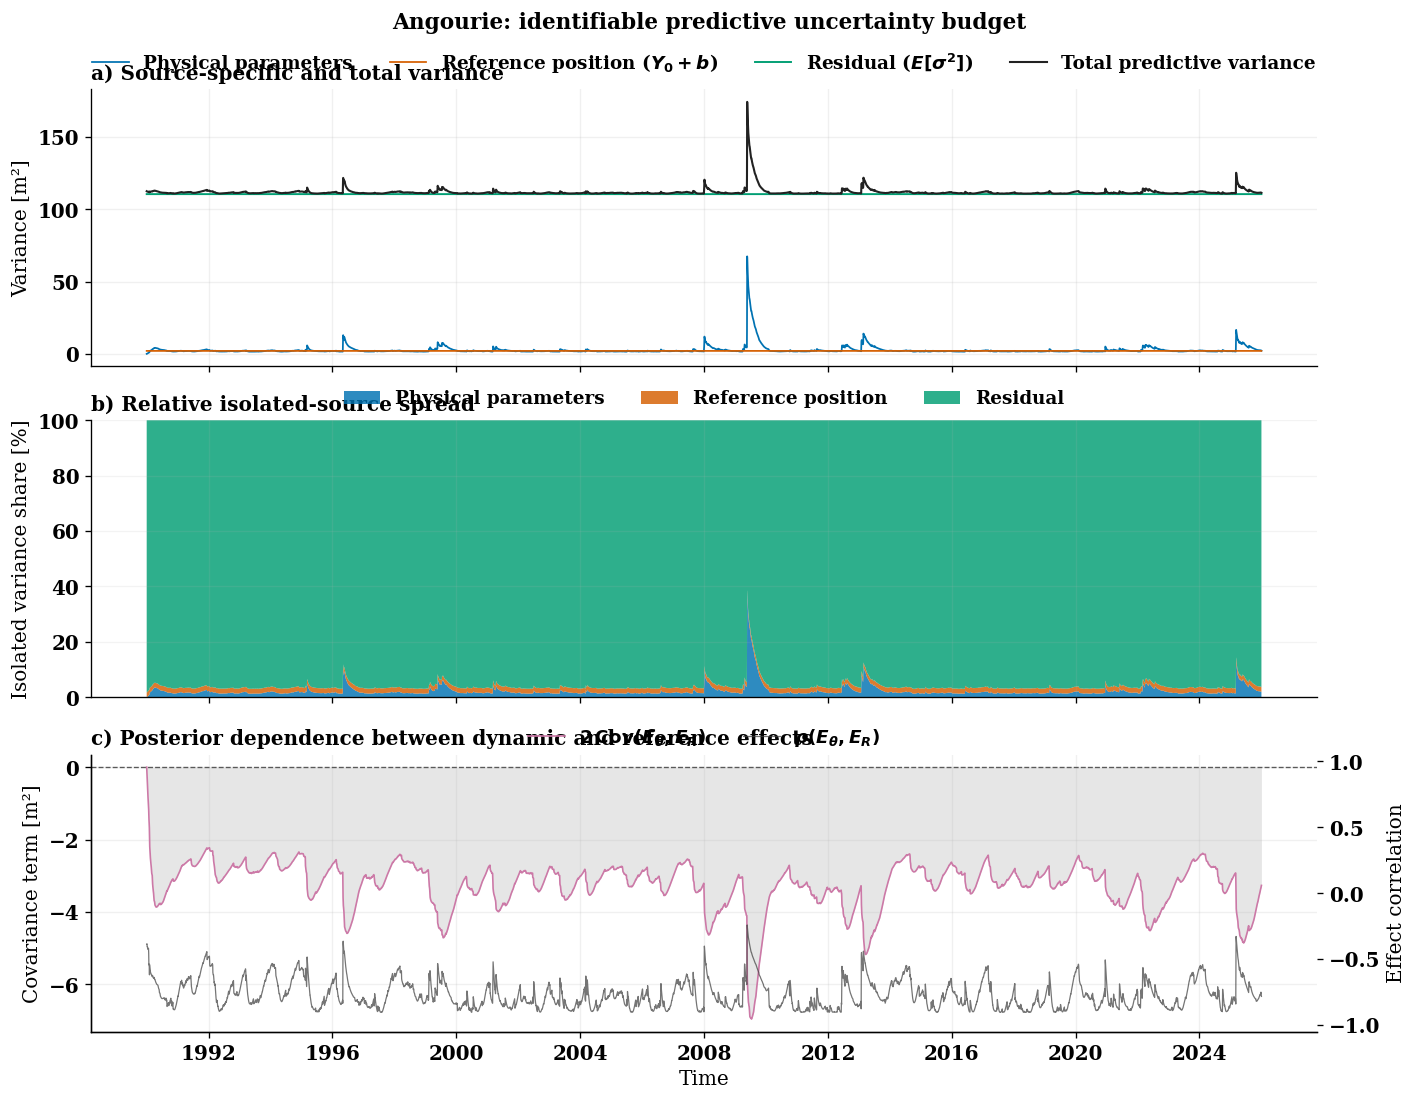

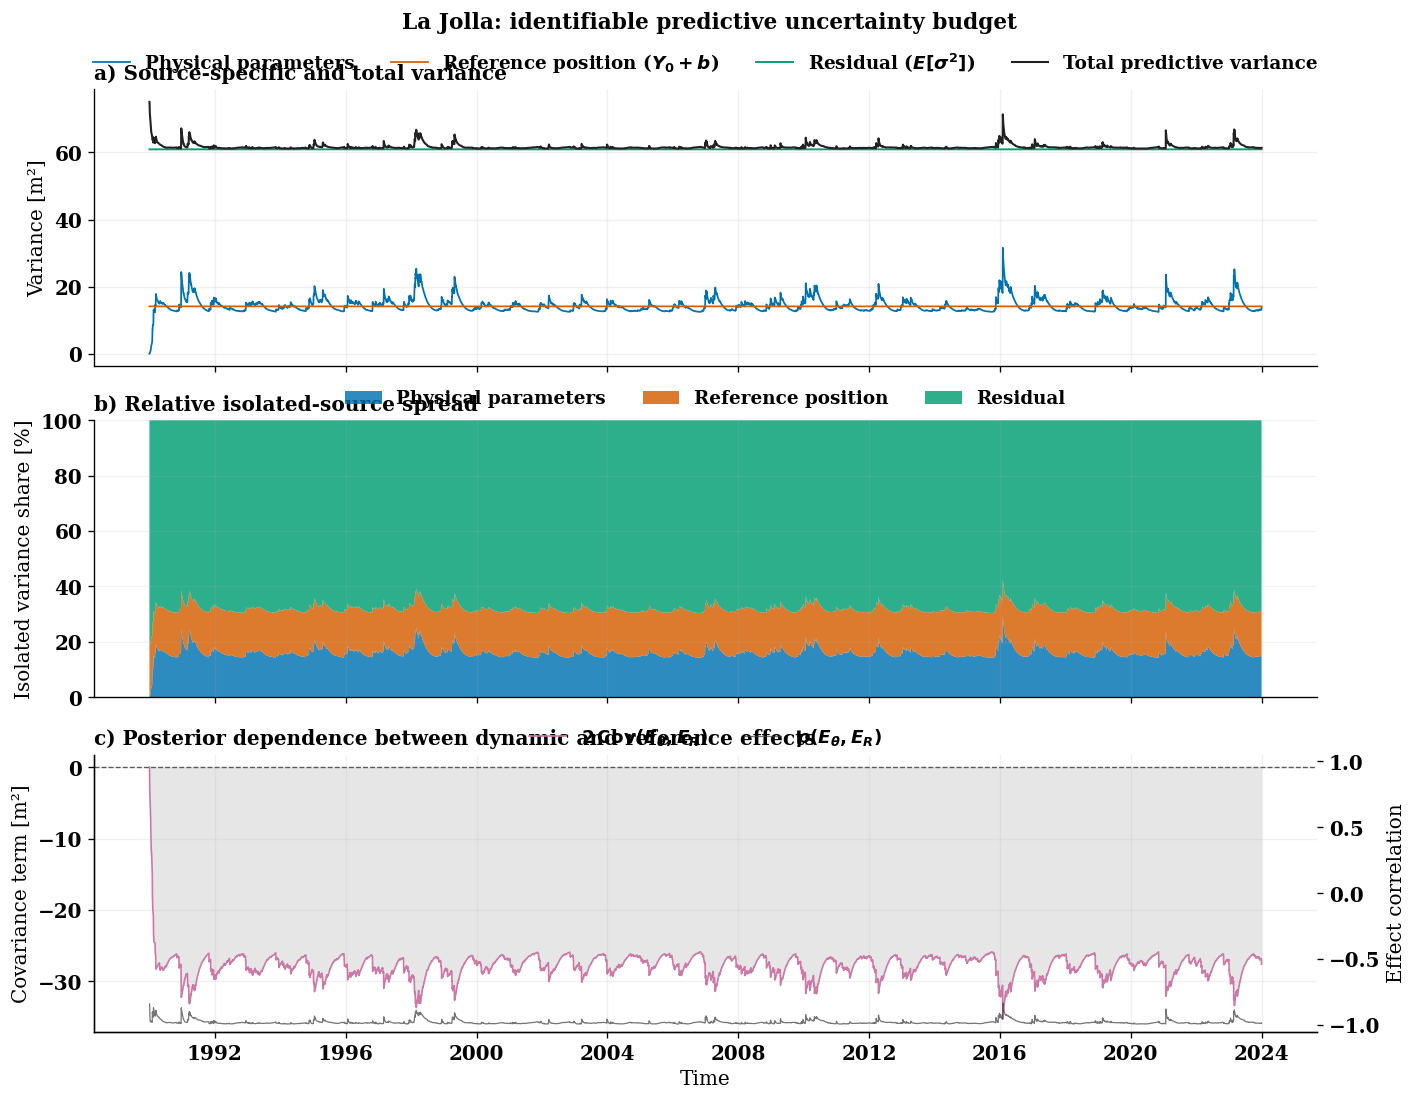

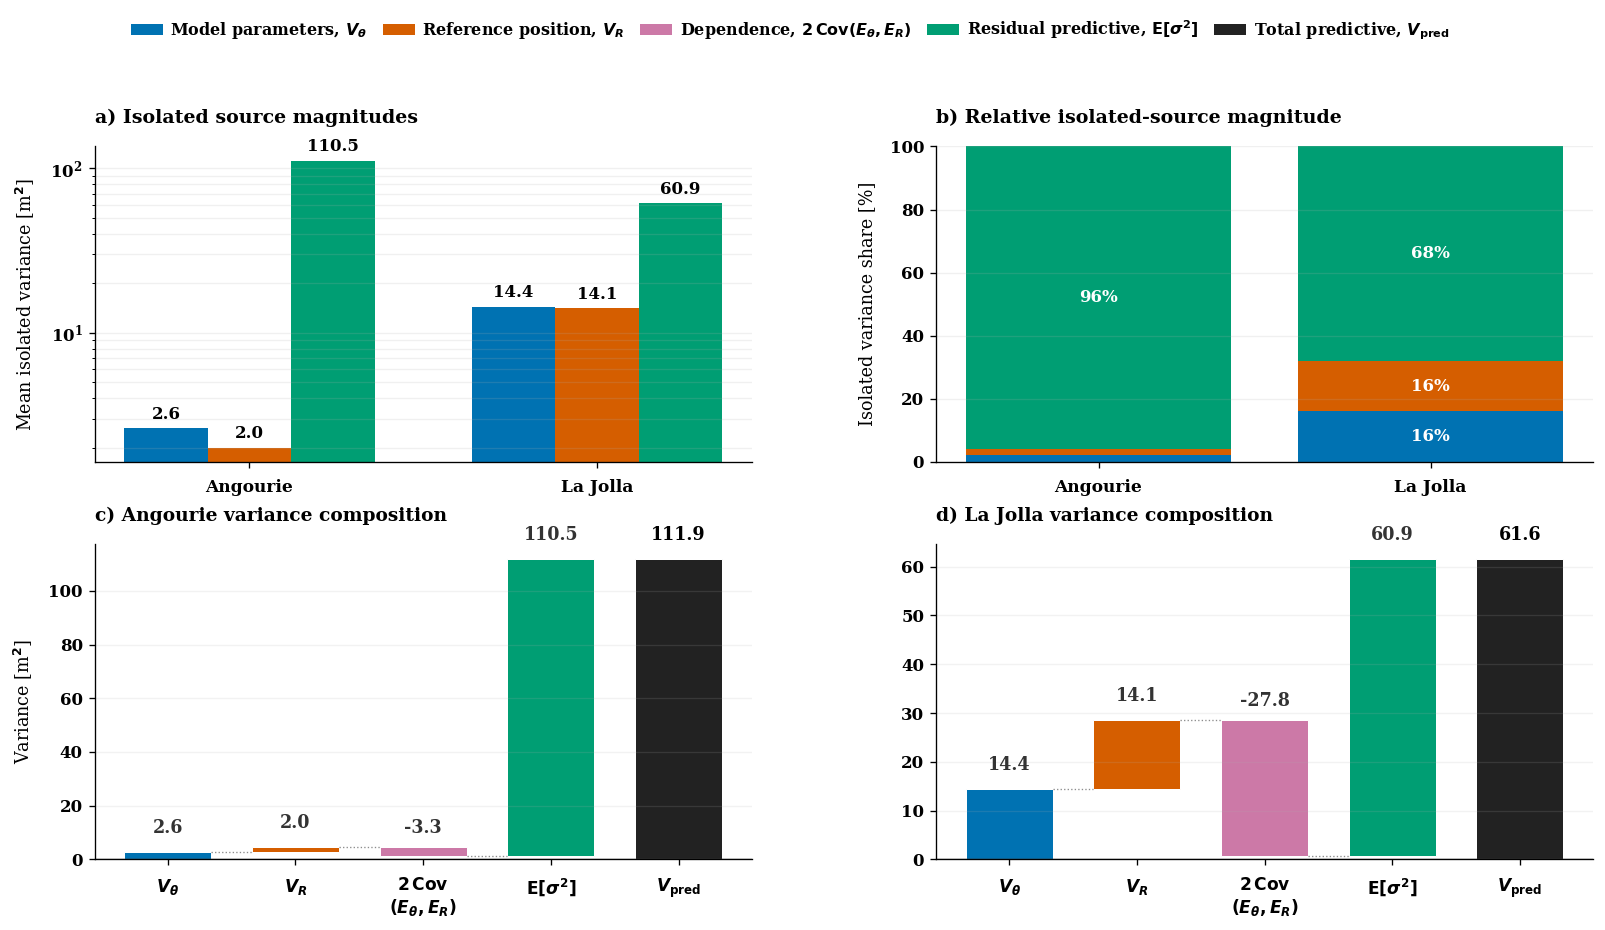

: 

In [ ]:
decomposition_results = {}

for site, artifact_dir in ARTIFACT_DIRS.items():
    if not artifact_dir.exists():
        continue

    df_budget, summary_budget, fig, axes = (
        decompose_identifiable_uncertainty_sources(
            artifact_dir,
            out_csv=(
                FIG_DIR
                / f"{site.replace(' ', '_')}_identifiable_variance_budget.csv"
            ),
            out_fig=(
                FIG_DIR
                / f"{site.replace(' ', '_')}_identifiable_variance_budget.png"
            ),
            title=(
                f"{site}: identifiable predictive uncertainty budget"
            ),
        )
    )

    decomposition_results[site] = {
        "data": df_budget,
        "summary": summary_budget,
    }

if decomposition_results:
    from matplotlib.patches import Patch

    comparison_rows = []
    for site, result in decomposition_results.items():
        summary = result["summary"]
        comparison_rows.append(
            {
                "site": site,
                "n_draws": int(summary["n_draws"]),
                "physical_parameter_variance_m2": float(
                    summary["mean_physical_parameter_variance_m2"]
                ),
                "reference_position_variance_m2": float(
                    summary["mean_reference_position_variance_m2"]
                ),
                "residual_predictive_variance_m2": float(
                    summary["residual_predictive_variance_m2"]
                ),
                "parameter_reference_covariance_m2": float(
                    summary["mean_twice_cov_parameters_reference_m2"]
                ),
                "latent_shoreline_variance_m2": float(
                    summary["mean_latent_shoreline_variance_m2"]
                ),
                "total_predictive_variance_m2": float(
                    summary["mean_total_predictive_variance_m2"]
                ),
                "total_predictive_sd_m": float(summary["mean_total_predictive_sd_m"]),
                "physical_parameter_share_%": float(
                    summary["physical_parameter_standalone_share_%"]
                ),
                "reference_position_share_%": float(
                    summary["reference_position_standalone_share_%"]
                ),
                "residual_predictive_share_%": float(
                    summary["residual_predictive_standalone_share_%"]
                ),
                "effect_correlation": float(
                    summary["mean_parameter_reference_effect_correlation"]
                ),
                "raw_y0_bias_spearman": float(
                    summary.get("raw_y0_bias_spearman", np.nan)
                ),
                "MC_variance_error_%": float(summary["mean_abs_MC_variance_error_%"]),
            }
        )

    uncertainty_comparison = (
        pd.DataFrame(comparison_rows).set_index("site").sort_index()
    )
    display(uncertainty_comparison.round(3))

    comparison_csv = FIG_DIR / "identifiable_uncertainty_site_comparison.csv"
    uncertainty_comparison.to_csv(comparison_csv)

    def _draw_variance_waterfall_spacious(ax, row, *, site):
        """Waterfall showing how isolated variances and covariance form the total."""
        components = [
            (r"$V_\theta$", float(row["physical_parameter_variance_m2"]), UNCERTAINTY_COLORS["parameter"]),
            (r"$V_R$", float(row["reference_position_variance_m2"]), UNCERTAINTY_COLORS["reference"]),
            (r"$2\,\mathrm{Cov}$" + "\n" + r"$(E_\theta,E_R)$", float(row["parameter_reference_covariance_m2"]), "#CC79A7"),
            (r"$\mathrm{E}[\sigma^2]$", float(row["residual_predictive_variance_m2"]), UNCERTAINTY_COLORS["residual"]),
        ]

        cumulative = 0.0
        for index, (label, value, color) in enumerate(components):
            bottom = cumulative if value >= 0.0 else cumulative + value
            height = value if value >= 0.0 else -value

            ax.bar(
                index,
                height,
                bottom=bottom,
                width=0.68,
                color=color,
                edgecolor="white",
                linewidth=0.6,
            )

            top_of_bar = bottom + height
            cumulative += value
            if index == 2:
                ax.annotate(
                    f"{value:.1f}",
                    xy=(index, top_of_bar),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=10.5,
                    color="0.20",
                    clip_on=False,
                )
            else:
                text_y = (
                    bottom + height + 0.05 * max(1.0, abs(row["total_predictive_variance_m2"]))
                    if value >= 0.0
                    else bottom - 0.05 * max(1.0, abs(row["total_predictive_variance_m2"]))
                )
                text_va = "bottom" if value >= 0.0 else "top"

                ax.text(
                    index,
                    text_y,
                    f"{value:.1f}",
                    ha="center",
                    va=text_va,
                    fontsize=10.5,
                    color="0.20",
                    clip_on=False,
                )

            if index < len(components) - 1:
                ax.plot(
                    [index + 0.34, index + 1 - 0.34],
                    [cumulative, cumulative],
                    color="0.55",
                    linewidth=0.8,
                    linestyle=":",
                )

        total = float(row["total_predictive_variance_m2"])
        ax.bar(
            len(components),
            total,
            width=0.68,
            color=UNCERTAINTY_COLORS["total"],
            edgecolor="white",
            linewidth=0.6,
        )
        ax.text(
            len(components),
            total + 0.05 * max(1.0, abs(total)),
            f"{total:.1f}",
            ha="center",
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            clip_on=False,
        )

        ax.axhline(0.0, color="0.35", linewidth=0.8)
        ax.set_xticks(np.arange(len(components) + 1))
        ax.set_xticklabels([item[0] for item in components] + [r"$V_{\mathrm{pred}}$"])
        ax.tick_params(axis="x", labelsize=10.2, pad=7)
        ax.tick_params(axis="y", labelsize=10.0)
        for tick in ax.get_xticklabels():
            tick.set_horizontalalignment("center")
        ax.set_title(site, loc="left", fontweight="bold", fontsize=11.2, pad=14)
        ax.grid(axis="y", alpha=0.16)

    plot_df = uncertainty_comparison.reset_index()
    x = np.arange(len(plot_df))
    width = 0.24

    fig = plt.figure(figsize=(13.8, 9.0), constrained_layout=False)
    gs = fig.add_gridspec(
        2,
        2,
        left=0.08,
        right=0.985,
        bottom=0.10,
        top=0.76,
        hspace=0.26,
        wspace=0.28,
    )

    ax_magnitude = fig.add_subplot(gs[0, 0])
    ax_share = fig.add_subplot(gs[0, 1])
    ax_waterfall_1 = fig.add_subplot(gs[1, 0])
    ax_waterfall_2 = fig.add_subplot(gs[1, 1])

    for offset, column, color in (
        (-width, "physical_parameter_variance_m2", UNCERTAINTY_COLORS["parameter"]),
        (0.0, "reference_position_variance_m2", UNCERTAINTY_COLORS["reference"]),
        (width, "residual_predictive_variance_m2", UNCERTAINTY_COLORS["residual"]),
    ):
        values = plot_df[column].to_numpy(dtype=float)
        bars = ax_magnitude.bar(x + offset, values, width, color=color)
        for bar, value in zip(bars, values):
            ax_magnitude.text(
                bar.get_x() + 0.5 * bar.get_width(),
                bar.get_height() * 1.08,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=10.0,
            )

    ax_magnitude.set_yscale("log")
    ax_magnitude.set_xticks(x)
    ax_magnitude.set_xticklabels(plot_df["site"], ha="center")
    ax_magnitude.tick_params(axis="x", labelsize=10.2, pad=7)
    ax_magnitude.tick_params(axis="y", labelsize=10.0)
    ax_magnitude.set_ylabel(r"Mean isolated variance [m$^2$]", fontsize=10.5, labelpad=8)
    ax_magnitude.set_title("a) Isolated source magnitudes", loc="left", fontweight="bold", fontsize=11.4, pad=14)
    ax_magnitude.grid(axis="y", alpha=0.18, which="both")

    share_bottom = np.zeros(len(plot_df))
    for column, color in (
        ("physical_parameter_share_%", UNCERTAINTY_COLORS["parameter"]),
        ("reference_position_share_%", UNCERTAINTY_COLORS["reference"]),
        ("residual_predictive_share_%", UNCERTAINTY_COLORS["residual"]),
    ):
        values = plot_df[column].to_numpy(dtype=float)
        ax_share.bar(x, values, bottom=share_bottom, color=color)
        for index, value in enumerate(values):
            if value >= 5.0:
                ax_share.text(
                    x[index],
                    share_bottom[index] + 0.5 * value,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=10.0,
                    color="white",
                    fontweight="bold",
                )
        share_bottom += values

    ax_share.set_xticks(x)
    ax_share.set_xticklabels(plot_df["site"], ha="center")
    ax_share.tick_params(axis="x", labelsize=10.2, pad=7)
    ax_share.tick_params(axis="y", labelsize=10.0)
    ax_share.set_ylim(0.0, 100.0)
    ax_share.set_ylabel("Isolated variance share [%]", fontsize=10.5, labelpad=8)
    ax_share.set_title("b) Relative isolated-source magnitude", loc="left", fontweight="bold", fontsize=11.4, pad=14)
    ax_share.grid(axis="y", alpha=0.18)

    _draw_variance_waterfall_spacious(
        ax_waterfall_1,
        plot_df.iloc[0],
        site="c) Angourie variance composition",
    )
    _draw_variance_waterfall_spacious(
        ax_waterfall_2,
        plot_df.iloc[1],
        site="d) La Jolla variance composition",
    )
    ax_waterfall_1.set_ylabel(r"Variance [m$^2$]", fontsize=10.5, labelpad=8)

    legend_handles = [
        Patch(facecolor=UNCERTAINTY_COLORS["parameter"], label=r"Model parameters, $V_\theta$"),
        Patch(facecolor=UNCERTAINTY_COLORS["reference"], label=r"Reference position, $V_R$"),
        Patch(facecolor="#CC79A7", label=r"Dependence, $2\,\mathrm{Cov}(E_\theta,E_R)$"),
        Patch(facecolor=UNCERTAINTY_COLORS["residual"], label=r"Residual predictive, $\mathrm{E}[\sigma^2]$"),
        Patch(facecolor=UNCERTAINTY_COLORS["total"], label=r"Total predictive, $V_{\mathrm{pred}}$"),
    ]
    fig.legend(
        handles=legend_handles,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.892),
        ncol=5,
        columnspacing=1.0,
        handletextpad=0.45,
        fontsize=9.6,
    )

    # fig.suptitle(
    #     "Identifiable predictive uncertainty across sites",
    #     fontsize=14.2,
    #     fontweight="bold",
    #     y=0.922,
    # )
    # fig.text(
    #     0.5,
    #     0.835,
    #     "Panels a–b show isolated magnitudes; panels c–d show the additive variance budget including posterior covariance.",
    #     ha="center",
    #     va="center",
    #     fontsize=9.8,
    #     color="0.35",
    # )

    fig.savefig(
        FIG_DIR / "identifiable_uncertainty_site_comparison_final.png",
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()
